In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score
import random
import os

# reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

import pandas as pd

eeg_path = "/content/drive/MyDrive/data_n_back_test/eeg/eeg.parquet"

In [ ]:
df = pd.read_parquet(eeg_path)

In [ ]:
# Filter phase 2
df = df[df["phase"] == 2].copy()

In [ ]:

# Filter phase 2
df = df[df["phase"] == 2].copy()

print(df.shape)
df.head()

(7694147, 142)


,timestamp,EEG.Counter,EEG.Interpolated,EEG.AF3,EEG.F7,EEG.F3,EEG.FC5,EEG.T7,EEG.P7,EEG.O1,...,POW.F8.Gamma,POW.AF4.Theta,POW.AF4.Alpha,POW.AF4.BetaL,POW.AF4.BetaH,POW.AF4.Gamma,datetime,subject,test,phase
82609,1.579252e+09,24,0,4206.922852,4209.871582,4217.051270,4212.307617,4206.666504,4210.000000,4215.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,2020-01-17 10:12:51.000058,subject_01,1,2
82610,1.579252e+09,25,0,4201.794922,4201.153809,4211.410156,4210.769043,4207.948730,4208.846191,4216.666504,...,NaN,NaN,NaN,NaN,NaN,NaN,2020-01-17 10:12:51.008038,subject_01,1,2
82611,1.579252e+09,26,0,4201.153809,4200.128418,4211.538574,4207.307617,4216.282227,4209.615234,4220.512695,...,NaN,NaN,NaN,NaN,NaN,NaN,2020-01-17 10:12:51.015919,subject_01,1,2
82612,1.579252e+09,27,0,4199.102539,4196.538574,4208.333496,4201.538574,4203.461426,4210.128418,4212.692383,...,NaN,NaN,NaN,NaN,NaN,NaN,2020-01-17 10:12:51.023899,subject_01,1,2
82613,1.579252e+09,28,0,4199.230957,4193.846191,4209.102539,4206.794922,4196.922852,4210.512695,4211.282227,...,NaN,NaN,NaN,NaN,NaN,NaN,2020-01-17 10:12:51.031779,subject_01,1,2


In [ ]:
# Filter phase 2
df = df[df["phase"] == 2].copy()

In [ ]:
print(df.shape)
df.head()


(7694147, 142)


,timestamp,EEG.Counter,EEG.Interpolated,EEG.AF3,EEG.F7,EEG.F3,EEG.FC5,EEG.T7,EEG.P7,EEG.O1,...,POW.F8.Gamma,POW.AF4.Theta,POW.AF4.Alpha,POW.AF4.BetaL,POW.AF4.BetaH,POW.AF4.Gamma,datetime,subject,test,phase
82609,1.579252e+09,24,0,4206.922852,4209.871582,4217.051270,4212.307617,4206.666504,4210.000000,4215.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,2020-01-17 10:12:51.000058,subject_01,1,2
82610,1.579252e+09,25,0,4201.794922,4201.153809,4211.410156,4210.769043,4207.948730,4208.846191,4216.666504,...,NaN,NaN,NaN,NaN,NaN,NaN,2020-01-17 10:12:51.008038,subject_01,1,2
82611,1.579252e+09,26,0,4201.153809,4200.128418,4211.538574,4207.307617,4216.282227,4209.615234,4220.512695,...,NaN,NaN,NaN,NaN,NaN,NaN,2020-01-17 10:12:51.015919,subject_01,1,2
82612,1.579252e+09,27,0,4199.102539,4196.538574,4208.333496,4201.538574,4203.461426,4210.128418,4212.692383,...,NaN,NaN,NaN,NaN,NaN,NaN,2020-01-17 10:12:51.023899,subject_01,1,2
82613,1.579252e+09,28,0,4199.230957,4193.846191,4209.102539,4206.794922,4196.922852,4210.512695,4211.282227,...,NaN,NaN,NaN,NaN,NaN,NaN,2020-01-17 10:12:51.031779,subject_01,1,2


In [ ]:
df["test"].shape

(7694147,)

In [ ]:
df["test"] = df["test"] - 1

In [ ]:
print(df["test"].value_counts())
print("Subjects:", df["subject"].nunique())

test
2    2601877
1    2561659
0    2530611
Name: count, dtype: int64
Subjects: 16


In [ ]:
eeg_cols = [c for c in df.columns if c not in ["subject","label","phase"]]


In [ ]:
eeg_cols = [
    'EEG.AF3','EEG.F7','EEG.F3','EEG.FC5',
    'EEG.T7','EEG.P7','EEG.O1','EEG.O2',
    'EEG.P8','EEG.T8','EEG.FC6','EEG.F4',
    'EEG.F8','EEG.AF4'
]

X_raw = df[eeg_cols].values          # (N_total_samples, 14)

In [ ]:
df["subject"]

,subject
82609,subject_01
82610,subject_01
82611,subject_01
82612,subject_01
82613,subject_01
...,...
15218596,subject_16
15218597,subject_16
15218598,subject_16
15218599,subject_16


In [ ]:
df.loc[True,eeg_cols].values

KeyError: 'True: boolean label can not be used without a boolean index'

In [ ]:
for subj in df["subject"].unique():
    idx = df["subject"] == subj
    X_sub = df.loc[idx, eeg_cols].values
    mu = X_sub.mean(axis=0, keepdims=True)
    sd = X_sub.std(axis=0, keepdims=True) + 1e-6
    df.loc[idx, eeg_cols] = (X_sub - mu) / sd

In [ ]:
X_sub.shape

(481704, 14)

In [ ]:
df = df.sort_values(["subject", "phase"]).copy()

In [ ]:
df = df.sort_values(["subject", "timestamp"]).copy()

In [ ]:
df = df.sort_values(["subject"]).copy()

In [ ]:
df["label_change"] = (
    df.groupby("subject")["test"]
    .diff()
    .fillna(0) != 0
)

In [ ]:
df["block_id"] = (
    df.groupby("subject")["label_change"]
    .cumsum()
)

In [ ]:
block_lengths = (
    df.groupby(["subject", "block_id"])
      .size()
      .reset_index(name="length")
)


In [ ]:
print(block_lengths.head())

      subject  block_id  length
0  subject_01         0       1
1  subject_01         1    2379
2  subject_01         2     235
3  subject_01         3       1
4  subject_01         4       2


In [ ]:

print("Block length stats (samples):")
print(block_lengths["length"].describe())

Block length stats (samples):
count      1007.000000
mean       7640.662363
std       17114.601331
min           1.000000
25%           1.000000
50%          85.000000
75%        5019.500000
max      124392.000000
Name: length, dtype: float64


In [ ]:
FS = 128
block_lengths["length_sec"] = block_lengths["length"] / FS

print("Block length stats (seconds):")
print(block_lengths["length_sec"].describe())


Block length stats (seconds):
count    1007.000000
mean       59.692675
std       133.707823
min         0.007812
25%         0.007812
50%         0.664062
75%        39.214844
max       971.812500
Name: length_sec, dtype: float64


In [ ]:
time_col = "timestamp"  # or "datetime" etc.

df2 = df[df["phase"] == 2].copy()
df2 = df2.sort_values(["subject", "test", time_col])

df2["test_change"] = df2.groupby(["subject", "test"])["test"].diff().fillna(0).ne(0)
df2["block_id"] = df2.groupby(["subject", "test"])["test_change"].cumsum()


In [ ]:
block_lengths = (
    df2.groupby(["subject", "test", "block_id"])
       .size()
       .reset_index(name="length")
)

(block_lengths["length"] / 128).describe()

,length
count,48.000000
mean,1252.302572
std,53.789981
min,1018.156250
25%,1225.390625
50%,1248.679688
75%,1278.236328
max,1439.507812


In [ ]:
df2 = df[df["phase"] == 2]
df2.groupby("subject")["test"].nunique().value_counts()

,count
test,
3,16


In [ ]:
FS = 128
WIN = int(2 * FS)
STRIDE = int(2 * FS)

X_all = []
y_all = []
s_all = []


In [ ]:
df["test"].values

array([0, 1, 1, ..., 2, 2, 0], dtype=int64)

In [ ]:
for subj, g in df.groupby("subject"):
    X = g[eeg_cols].values.astype(np.float32)
    y = g["test"].values

    n = (len(X) - WIN) // STRIDE + 1

    for i in range(n):
        a = i * STRIDE
        b = a + WIN
        seg = X[a:b]
        lab = y[a:b]

        # majority label
        vals, counts = np.unique(lab, return_counts=True)
        maj = vals[np.argmax(counts)]

        X_all.append(seg.T)  # channel-first
        y_all.append(maj)
        s_all.append(subj)

X_all = np.stack(X_all)
y_all = np.array(y_all)
s_all = np.array(s_all)

print(X_all.shape)

(30047, 14, 256)


In [ ]:
unique_vals = np.unique(s_all)

print(unique_vals)

['subject_01' 'subject_02' 'subject_03' 'subject_04' 'subject_05'
 'subject_06' 'subject_07' 'subject_08' 'subject_09' 'subject_10'
 'subject_11' 'subject_12' 'subject_13' 'subject_14' 'subject_15'
 'subject_16']


In [ ]:
unique_vals, counts = np.unique(s_all, return_counts=True)
print(unique_vals)
print(counts)

['subject_01' 'subject_02' 'subject_03' 'subject_04' 'subject_05'
 'subject_06' 'subject_07' 'subject_08' 'subject_09' 'subject_10'
 'subject_11' 'subject_12' 'subject_13' 'subject_14' 'subject_15'
 'subject_16']
[1903 1881 1886 1943 1913 1861 1842 1861 1848 1809 1908 1898 1882 1905
 1826 1881]


In [ ]:
unique_subjects = sorted(np.unique(s_all))
first5 = unique_subjects[:5]


In [ ]:
import numpy as np
from scipy.signal import welch

FS = 256
ALPHA_LOW = 8
ALPHA_HIGH = 12

# isolate subject 5
mask_5 = (s_all == "subject_05")
X_5 = X_all[mask_5]
y_5 = y_all[mask_5]

def compute_alpha_power(trial):
    # trial shape: (C, T)
    psds = []
    for ch in trial:
        f, Pxx = welch(ch, fs=FS, nperseg=128)
        alpha_mask = (f >= ALPHA_LOW) & (f <= ALPHA_HIGH)
        psds.append(np.mean(Pxx[alpha_mask]))
    return np.mean(psds)

alpha_powers = np.array([compute_alpha_power(trial) for trial in X_5])

In [ ]:
for label in np.unique(y_5):
    mean_alpha = np.mean(alpha_powers[y_5 == label])
    print(f"Class {label} mean alpha power:", mean_alpha)


Class 0 mean alpha power: 0.010250167
Class 1 mean alpha power: 0.018107269
Class 2 mean alpha power: 0.015503075


In [ ]:
def cohens_d(a, b):
    return (np.mean(a) - np.mean(b)) / np.sqrt((np.var(a) + np.var(b)) / 2)

class0 = alpha_powers[y_5 == 0]
class2 = alpha_powers[y_5 == 2]

print("Cohen's d (0 vs 2):", cohens_d(class0, class2))

Cohen's d (0 vs 2): -0.34168565


In [ ]:
import numpy as np
from scipy.signal import welch

FS = 256
THETA_LOW = 4
THETA_HIGH = 7

# isolate subject 5
mask_5 = (s_all == "subject_05")
X_5 = X_all[mask_5]
y_5 = y_all[mask_5]

print("Subject 5 shape:", X_5.shape)

Subject 5 shape: (1913, 14, 256)


In [ ]:
def compute_band_power(trial, low, high):
    # trial shape: (C, T)
    band_powers = []

    for ch in trial:
        f, Pxx = welch(ch, fs=FS, nperseg=128)
        band_mask = (f >= low) & (f <= high)
        band_powers.append(np.mean(Pxx[band_mask]))

    return np.mean(band_powers)  # average across channels

In [ ]:
theta_powers = np.array([
    compute_band_power(trial, THETA_LOW, THETA_HIGH)
    for trial in X_5
])

In [ ]:
def cohens_d(a, b):
    return (np.mean(a) - np.mean(b)) / np.sqrt((np.var(a) + np.var(b)) / 2)

In [ ]:
class0 = theta_powers[y_5 == 0]
class2 = theta_powers[y_5 == 2]

print("Theta whole-brain means:")
print("Class 0:", np.mean(class0))
print("Class 2:", np.mean(class2))

print("Cohen's d (0 vs 2):", cohens_d(class0, class2))

Theta whole-brain means:
Class 0: 0.02922514
Class 2: 0.042093404
Cohen's d (0 vs 2): -0.26972628


In [ ]:
import numpy as np
from scipy.signal import welch

FS = 256

BANDS = {
    "theta": (4, 7),
    "alpha": (8, 12),
    "beta":  (13, 30),
}

def bandpower_trial(trial, band, fs=FS, nperseg=128):
    """
    trial: (C, T)
    returns: scalar bandpower averaged over channels
    """
    low, high = band
    ch_p = []
    for ch in trial:
        f, Pxx = welch(ch, fs=fs, nperseg=nperseg)
        m = (f >= low) & (f <= high)
        ch_p.append(np.mean(Pxx[m]))
    return float(np.mean(ch_p))

def cohens_d(a, b, eps=1e-12):
    a = np.asarray(a); b = np.asarray(b)
    va = np.var(a); vb = np.var(b)
    denom = np.sqrt((va + vb) / 2.0) + eps
    return float((np.mean(a) - np.mean(b)) / denom)

In [ ]:

def per_subject_effects(X_all, y_all, s_all, class_a=0, class_b=2, bands=BANDS):
    subjects = np.unique(s_all)
    rows = []

    for subj in subjects:
        idx = (s_all == subj)
        X = X_all[idx]
        y = y_all[idx]

        # require both classes present
        if not (np.any(y == class_a) and np.any(y == class_b)):
            continue

        # compute bandpower per trial for each band
        bp = {name: np.array([bandpower_trial(tr, band) for tr in X])
              for name, band in bands.items()}

        row = {"subject": subj, "n": int(X.shape[0])}
        for name in bands.keys():
            a = bp[name][y == class_a]
            b = bp[name][y == class_b]
            row[f"{name}_mean_{class_a}"] = float(np.mean(a))
            row[f"{name}_mean_{class_b}"] = float(np.mean(b))
            row[f"{name}_d_{class_a}v{class_b}"] = cohens_d(a, b)
        rows.append(row)

    return rows


In [ ]:
import numpy as np
from scipy.signal import welch

FS = 256

def bandpower_trial(trial, low, high):
    ch_p = []
    for ch in trial:
        f, Pxx = welch(ch, fs=FS, nperseg=128)
        m = (f >= low) & (f <= high)
        ch_p.append(np.mean(Pxx[m]))
    return np.mean(ch_p)

def cohens_d(a, b):
    return (np.mean(a) - np.mean(b)) / np.sqrt((np.var(a) + np.var(b)) / 2 + 1e-12)

subjects_to_check = ["subject_05", "subject_04", "subject_06"]

for subj in subjects_to_check:
    idx = (s_all == subj)
    X = X_all[idx]
    y = y_all[idx]

    if not (np.any(y == 0) and np.any(y == 2)):
        continue

    alpha = np.array([bandpower_trial(tr, 8, 12) for tr in X])
    theta = np.array([bandpower_trial(tr, 4, 7) for tr in X])

    a0 = alpha[y == 0]
    a2 = alpha[y == 2]
    t0 = theta[y == 0]
    t2 = theta[y == 2]

    print(f"\n{subj}")
    print("Alpha d (0 vs 2):", cohens_d(a0, a2))
    print("Theta d (0 vs 2):", cohens_d(t0, t2))



subject_05
Alpha d (0 vs 2): -0.34168565
Theta d (0 vs 2): -0.26972628

subject_04
Alpha d (0 vs 2): 0.16967794
Theta d (0 vs 2): 0.19463181

subject_06
Alpha d (0 vs 2): 0.13019451
Theta d (0 vs 2): 0.1606415


In [ ]:
print("Using subjects:", first5)

mask_5 = np.isin(s_all, first5)

X_small = X_all[mask_5]
y_small = y_all[mask_5]
s_small = s_all[mask_5]

Using subjects: [np.str_('subject_01'), np.str_('subject_02'), np.str_('subject_03'), np.str_('subject_04'), np.str_('subject_05')]


In [ ]:
TEST_SUBJECT = first5[0]   # first subject as test

mask = s_small == TEST_SUBJECT

X_train = X_small[~mask]
y_train = y_small[~mask]
s_train = s_small[~mask]

X_test = X_small[mask]
y_test = y_small[mask]
s_test = s_small[mask]


In [ ]:
print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (7623, 14, 256)
Test: (1903, 14, 256)


In [ ]:
print("Train label distribution:", np.bincount(y_train))

Train label distribution: [2525 2550 2548]


In [ ]:
print("Test label distribution:", np.bincount(y_test))

Test label distribution: [655 622 626]


In [ ]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat  = X_test.reshape(len(X_test), -1)

In [ ]:
print(X_train_flat.shape)

(7623, 3584)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

clf = LogisticRegression(max_iter=2000, n_jobs=-1)
clf.fit(X_train_flat, y_train)

train_pred = clf.predict(X_train_flat)
test_pred  = clf.predict(X_test_flat)

print("Train Acc:", accuracy_score(y_train, train_pred))
print("Test Acc:", accuracy_score(y_test, test_pred))

Train Acc: 0.9118457300275482
Test Acc: 0.2879663688912244


In [ ]:
unique_subjects = sorted(np.unique(s_small))
subj_A = unique_subjects[0]
subj_B = unique_subjects[1]

print("Train on:", subj_A)
print("Test on:", subj_B)

Train on: subject_01
Test on: subject_02


In [ ]:
mask_A = s_small == subj_A
mask_B = s_small == subj_B

X_A = X_small[mask_A]
y_A = y_small[mask_A]

X_B = X_small[mask_B]
y_B = y_small[mask_B]

print("A shape:", X_A.shape)
print("B shape:", X_B.shape)

A shape: (1903, 14, 256)
B shape: (1881, 14, 256)


In [ ]:
X_A_flat = X_A.reshape(len(X_A), -1)
X_B_flat = X_B.reshape(len(X_B), -1)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

clf = LogisticRegression(max_iter=3000)

clf.fit(X_A_flat, y_A)

train_acc = clf.score(X_A_flat, y_A)
test_acc  = clf.score(X_B_flat, y_B)

print("Train (A→A):", train_acc)
print("Test  (A→B):", test_acc)

Train (A→A): 1.0
Test  (A→B): 0.3902179691653376


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Within subject
train_pred = clf.predict(X_A_flat)

# Cross subject
test_pred = clf.predict(X_B_flat)

In [ ]:
cm_train = confusion_matrix(y_A, train_pred)
print("Confusion Matrix (A→A):")
print(cm_train)

Confusion Matrix (A→A):
[[655   0   0]
 [  0 622   0]
 [  0   0 626]]


In [ ]:
cm_test = confusion_matrix(y_B, test_pred)
print("Confusion Matrix (A→B):")
print(cm_test)

Confusion Matrix (A→B):
[[264 225 143]
 [238 184 200]
 [245  96 286]]


In [ ]:
cm_test = confusion_matrix(y_B, test_pred)
print("Confusion Matrix (A→B):")
print(cm_test)

Confusion Matrix (A→B):
[[264 225 143]
 [238 184 200]
 [245  96 286]]


In [ ]:
subj = subj_A  # or any subject
mask = s_small == subj
X_sub = X_small[mask]

print("Mean per channel:", X_sub.mean(axis=(0,2)))
print("Std per channel:", X_sub.std(axis=(0,2)))

Mean per channel: [-6.15752651e-05 -3.03117176e-05 -9.80406112e-05 -1.18459160e-04
  5.59661639e-05 -1.31150082e-04  1.02139733e-04  1.29110258e-05
  4.78208640e-05  5.72805175e-06 -4.87218640e-05 -1.01459664e-04
  5.31428032e-06 -1.50800974e-04]
Std per channel: [1.0002152 1.0002172 1.0001719 1.0001787 1.0001856 1.000229  1.0001664
 1.0001787 1.0001671 1.0002192 1.000163  1.0001568 1.0001917 1.0001689]


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# --- pick two subjects (same ones as before) ---
unique_subjects = sorted(np.unique(s_small))
subj_A = unique_subjects[0]
subj_B = unique_subjects[1]

# --- extract windows ---
mask_A = (s_small == subj_A)
mask_B = (s_small == subj_B)

X_A = X_small[mask_A]
y_A = y_small[mask_A]

X_B = X_small[mask_B]
y_B = y_small[mask_B]

# --- flatten ---
X_A_flat = X_A.reshape(len(X_A), -1)
X_B_flat = X_B.reshape(len(X_B), -1)

# =========================
# Train on B, test on A
# =========================
clf_BA = LogisticRegression(max_iter=3000)
clf_BA.fit(X_B_flat, y_B)

train_pred_B = clf_BA.predict(X_B_flat)
test_pred_A  = clf_BA.predict(X_A_flat)

train_acc_BA = accuracy_score(y_B, train_pred_B)
test_acc_BA  = accuracy_score(y_A, test_pred_A)

print("Train (B→B):", train_acc_BA)
print("Test  (B→A):", test_acc_BA)

print("\nConfusion Matrix (B→B):")
print(confusion_matrix(y_B, train_pred_B))

print("\nConfusion Matrix (B→A):")
print(confusion_matrix(y_A, test_pred_A))

Train (B→B): 0.9994683678894205
Test  (B→A): 0.418286915396742

Confusion Matrix (B→B):
[[632   0   0]
 [  0 622   0]
 [  0   1 626]]

Confusion Matrix (B→A):
[[253 166 236]
 [211 241 170]
 [150 174 302]]


In [ ]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# combine A and B
X_vis = np.concatenate([X_A_flat, X_B_flat], axis=0)
y_vis = np.concatenate([y_A, y_B], axis=0)

subject_labels = np.array(
    ["A"] * len(X_A_flat) + ["B"] * len(X_B_flat)
)

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_vis)

print("Explained variance:", pca.explained_variance_ratio_)

Explained variance: [0.08982845 0.06202934]


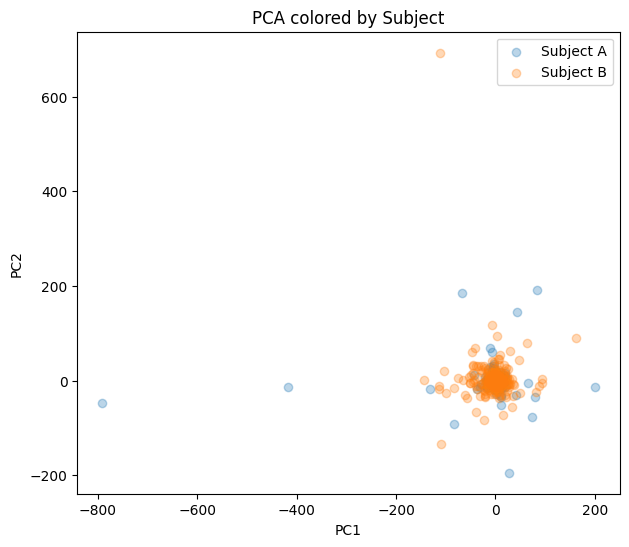

In [ ]:
plt.figure(figsize=(7,6))

for subj in ["A", "B"]:
    idx = subject_labels == subj
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1],
                alpha=0.3, label=f"Subject {subj}")

plt.legend()
plt.title("PCA colored by Subject")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

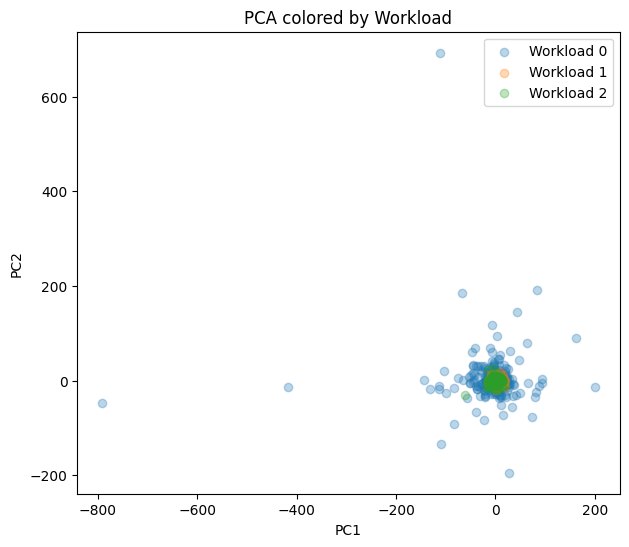

In [ ]:
plt.figure(figsize=(7,6))

for cls in [0,1,2]:
    idx = y_vis == cls
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1],
                alpha=0.3, label=f"Workload {cls}")

plt.legend()
plt.title("PCA colored by Workload")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [ ]:
print("Max abs value in X_A_flat:", np.abs(X_A_flat).max())
print("Max abs value in X_B_flat:", np.abs(X_B_flat).max())


Max abs value in X_A_flat: 94.336555
Max abs value in X_B_flat: 58.291145


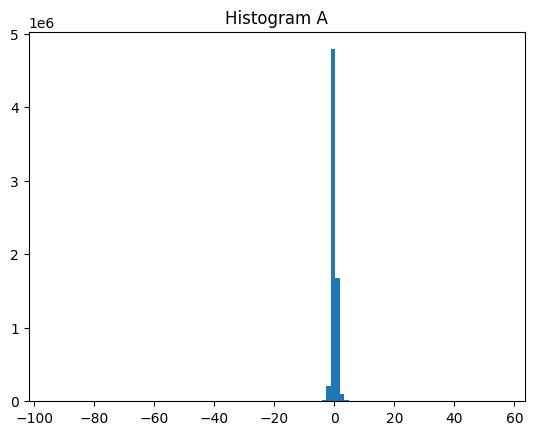

In [ ]:
plt.hist(X_A_flat.flatten(), bins=100)
plt.title("Histogram A")
plt.show()

In [ ]:
# binary subject classifier
subject_binary = np.array([0]*len(X_A_flat) + [1]*len(X_B_flat))

clf_subj = LogisticRegression(max_iter=3000)
clf_subj.fit(X_vis, subject_binary)

print("Subject classification accuracy:",
      clf_subj.score(X_vis, subject_binary))

Subject classification accuracy: 0.9997357293868921


In [ ]:
from sklearn.linear_model import LogisticRegression
import numpy as np

def subject_classification_test(subject_list):
    mask = np.isin(s_all, subject_list)

    X = X_all[mask]
    s = s_all[mask]

    # encode subjects to integers
    unique = sorted(np.unique(s))
    subj_map = {subj:i for i,subj in enumerate(unique)}
    s_encoded = np.array([subj_map[subj] for subj in s])

    X_flat = X.reshape(len(X), -1)

    clf = LogisticRegression(max_iter=3000, multi_class="multinomial")
    clf.fit(X_flat, s_encoded)

    acc = clf.score(X_flat, s_encoded)

    print(f"Subjects: {len(unique)} | Accuracy: {acc:.4f}")

In [ ]:
unique_subjects = sorted(np.unique(s_all))

# 5 subjects
subject_classification_test(unique_subjects[:5])

# 10 subjects
subject_classification_test(unique_subjects[:10])

# 16 subjects
subject_classification_test(unique_subjects)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Subjects: 5 | Accuracy: 0.9333


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
X_all_flat = X_all.reshape(len(X_all), -1)

In [ ]:
from sklearn.linear_model import SGDClassifier

clf = SGDClassifier(loss="log_loss", max_iter=1000, n_jobs=-1)
clf.fit(X, s_encoded)


NameError: name 's_encoded' is not defined

In [ ]:
import numpy as np
from sklearn.linear_model import SGDClassifier

# ---- 1. Precompute flattened once ----
X_all_flat = X_all.reshape(len(X_all), -1)

def subject_classification_fast(subject_list, n_per_subject=1000):

    mask = np.isin(s_all, subject_list)

    X = X_all_flat[mask]
    s = s_all[mask]

    # ---- 2. Subsample per subject ----
    X_list = []
    s_list = []

    for subj in np.unique(s):
        idx = np.where(s == subj)[0]

        if len(idx) > n_per_subject:
            idx = np.random.choice(idx, n_per_subject, replace=False)

        X_list.append(X[idx])
        s_list.append(s[idx])

    X = np.concatenate(X_list)
    s = np.concatenate(s_list)

    # ---- 3. Encode subjects ----
    unique = sorted(np.unique(s))
    subj_map = {subj:i for i,subj in enumerate(unique)}
    s_encoded = np.array([subj_map[subj] for subj in s])

    # ---- 4. Train classifier ----
    clf = SGDClassifier(loss="log_loss", max_iter=1000)
    clf.fit(X, s_encoded)

    acc = clf.score(X, s_encoded)

    print(f"Subjects: {len(unique)} | Accuracy: {acc:.4f}")

In [ ]:
unique_subjects = sorted(np.unique(s_all))

subject_classification_fast(unique_subjects[:5])
subject_classification_fast(unique_subjects[:10])
subject_classification_fast(unique_subjects)

Subjects: 5 | Accuracy: 0.7432
Subjects: 10 | Accuracy: 0.6821


KeyboardInterrupt: 

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ---- select first 5 subjects ----
unique_subjects = sorted(np.unique(s_all))
first5 = unique_subjects[:5]

print("Using subjects:", first5)

mask5 = np.isin(s_all, first5)

X_small = X_all[mask5]
y_small = y_all[mask5]
s_small = s_all[mask5]

print("X_small:", X_small.shape)
print("y_small:", y_small.shape)
print("s_small unique:", np.unique(s_small))

Device: cuda
Using subjects: [np.str_('subject_01'), np.str_('subject_02'), np.str_('subject_03'), np.str_('subject_04'), np.str_('subject_05')]
X_small: (9526, 14, 256)
y_small: (9526,)
s_small unique: ['subject_01' 'subject_02' 'subject_03' 'subject_04' 'subject_05']


In [ ]:
TEST_SUBJECT = first5[0]
print("Test subject:", TEST_SUBJECT)

mask_test = s_small == TEST_SUBJECT

X_train = X_small[~mask_test]
y_train = y_small[~mask_test]
s_train = s_small[~mask_test]

X_test  = X_small[mask_test]
y_test  = y_small[mask_test]
s_test  = s_small[mask_test]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("Train label distribution:", np.bincount(y_train))
print("Test label distribution:", np.bincount(y_test))

Test subject: subject_01
Train shape: (7623, 14, 256)
Test shape: (1903, 14, 256)
Train label distribution: [2525 2550 2548]
Test label distribution: [655 622 626]


In [ ]:
train_subjects_unique = sorted(np.unique(s_train))
print("Train subjects:", train_subjects_unique)

subj_map = {subj:i for i,subj in enumerate(train_subjects_unique)}

s_train_encoded = np.array([subj_map[s] for s in s_train])

print("Encoded subject labels example:", s_train_encoded[:10])
print("Number of train subjects:", len(train_subjects_unique))

Train subjects: [np.str_('subject_02'), np.str_('subject_03'), np.str_('subject_04'), np.str_('subject_05')]
Encoded subject labels example: [0 0 0 0 0 0 0 0 0 0]
Number of train subjects: 4


In [ ]:
encoded_unique = sorted(np.unique(s_train_encoded))
print("Unique encoded subject IDs:", encoded_unique)
print("Count:", len(encoded_unique))

Unique encoded subject IDs: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Count: 4


In [ ]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
s_train_t = torch.tensor(s_train_encoded, dtype=torch.long)

X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

print("Tensor shapes:")
print(X_train_t.shape, y_train_t.shape, s_train_t.shape)
print(X_test_t.shape, y_test_t.shape)


Tensor shapes:
torch.Size([7623, 14, 256]) torch.Size([7623]) torch.Size([7623])
torch.Size([1903, 14, 256]) torch.Size([1903])


In [ ]:
train_ds = TensorDataset(X_train_t, y_train_t, s_train_t)
test_ds  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 30
Test batches: 8


In [ ]:
class GradReverse(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambd):
        ctx.lambd = lambd
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambd * grad_output, None

def grad_reverse(x, lambd=1.0):
    return GradReverse.apply(x, lambd)

In [ ]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(14, 32, kernel_size=7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm1d(32)

        self.conv2 = nn.Conv1d(32, 64, kernel_size=7, stride=2, padding=3)
        self.bn2 = nn.BatchNorm1d(64)

        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(64, 128)

    def forward(self, x):
        x = F.gelu(self.bn1(self.conv1(x)))
        x = F.gelu(self.bn2(self.conv2(x)))
        x = self.pool(x).squeeze(-1)
        z = self.fc(x)
        return z


class Model(nn.Module):
    def __init__(self, n_subjects):
        super().__init__()
        self.encoder = Encoder()
        self.workload_head = nn.Linear(128, 3)
        self.subject_head = nn.Linear(128, n_subjects)

    def forward(self, x, lambd=0.0):
        z = self.encoder(x)

        workload_logits = self.workload_head(z)

        z_rev = grad_reverse(z, lambd)
        subject_logits = self.subject_head(z_rev)

        return workload_logits, subject_logits

In [ ]:
model = Model(n_subjects=len(train_subjects_unique)).to(device)

print(model)


Model(
  (encoder): Encoder(
    (conv1): Conv1d(14, 32, kernel_size=(7,), stride=(2,), padding=(3,))
    (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv1d(32, 64, kernel_size=(7,), stride=(2,), padding=(3,))
    (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool): AdaptiveAvgPool1d(output_size=1)
    (fc): Linear(in_features=64, out_features=128, bias=True)
  )
  (workload_head): Linear(in_features=128, out_features=3, bias=True)
  (subject_head): Linear(in_features=128, out_features=4, bias=True)
)


In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

EPOCHS = 30

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0
    correct_work = 0
    total_work = 0

    for x, y, s in train_loader:
        x = x.to(device)
        y = y.to(device)
        s = s.to(device)

        lambd = min(1.0, epoch / 10)  # gradually increase adversarial strength

        workload_logits, subject_logits = model(x, lambd=lambd)

        loss_work = F.cross_entropy(workload_logits, y)
        loss_subj = F.cross_entropy(subject_logits, s)

        loss = loss_work + 0.5 * loss_subj

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = workload_logits.argmax(dim=1)
        correct_work += (preds == y).sum().item()
        total_work += y.size(0)

    train_acc = correct_work / total_work

    # ---- evaluation ----
    model.eval()
    correct_test = 0
    total_test = 0

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            y = y.to(device)

            logits, _ = model(x, lambd=0.0)
            preds = logits.argmax(dim=1)

            correct_test += (preds == y).sum().item()
            total_test += y.size(0)

    test_acc = correct_test / total_test

    print(f"Epoch {epoch+1:02d} | "
          f"Loss: {total_loss/len(train_loader):.4f} | "
          f"Train Acc: {train_acc:.4f} | "
          f"Test Acc: {test_acc:.4f}")


Epoch 01 | Loss: 1.7315 | Train Acc: 0.4969 | Test Acc: 0.1892
Epoch 02 | Loss: 1.5644 | Train Acc: 0.6152 | Test Acc: 0.1981
Epoch 03 | Loss: 1.4373 | Train Acc: 0.6794 | Test Acc: 0.3043
Epoch 04 | Loss: 1.3650 | Train Acc: 0.7206 | Test Acc: 0.3531
Epoch 05 | Loss: 1.3340 | Train Acc: 0.7455 | Test Acc: 0.3678
Epoch 06 | Loss: 1.3141 | Train Acc: 0.7662 | Test Acc: 0.3988
Epoch 07 | Loss: 1.3135 | Train Acc: 0.7717 | Test Acc: 0.4104
Epoch 08 | Loss: 1.2906 | Train Acc: 0.7815 | Test Acc: 0.4241
Epoch 09 | Loss: 1.2471 | Train Acc: 0.7990 | Test Acc: 0.4398
Epoch 10 | Loss: 1.2113 | Train Acc: 0.8061 | Test Acc: 0.5071
Epoch 11 | Loss: 1.2049 | Train Acc: 0.8087 | Test Acc: 0.5150
Epoch 12 | Loss: 1.1937 | Train Acc: 0.8209 | Test Acc: 0.4787
Epoch 13 | Loss: 1.1810 | Train Acc: 0.8251 | Test Acc: 0.4493
Epoch 14 | Loss: 1.1606 | Train Acc: 0.8283 | Test Acc: 0.5139
Epoch 15 | Loss: 1.1313 | Train Acc: 0.8276 | Test Acc: 0.4992
Epoch 16 | Loss: 1.1053 | Train Acc: 0.8333 | Test Acc:

In [ ]:
model = Model(n_subjects=len(train_subjects_unique)).to(device)

print(model)


Model(
  (encoder): Encoder(
    (conv1): Conv1d(14, 32, kernel_size=(7,), stride=(2,), padding=(3,))
    (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv1d(32, 64, kernel_size=(7,), stride=(2,), padding=(3,))
    (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool): AdaptiveAvgPool1d(output_size=1)
    (fc): Linear(in_features=64, out_features=128, bias=True)
  )
  (workload_head): Linear(in_features=128, out_features=3, bias=True)
  (subject_head): Linear(in_features=128, out_features=4, bias=True)
)


In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

EPOCHS = 30

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    correct_work = 0
    total_work = 0

    correct_subj = 0
    total_subj = 0

    for x, y, s in train_loader:
        x = x.to(device)
        y = y.to(device)
        s = s.to(device)

        lambd = min(1.0, epoch / 10)

        workload_logits, subject_logits = model(x, lambd=lambd)

        loss_work = F.cross_entropy(workload_logits, y)
        loss_subj = F.cross_entropy(subject_logits, s)

        loss = loss_work + 0.5 * loss_subj

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # ---- workload accuracy ----
        preds_work = workload_logits.argmax(dim=1)
        correct_work += (preds_work == y).sum().item()
        total_work += y.size(0)

        # ---- subject accuracy ----
        preds_subj = subject_logits.argmax(dim=1)
        correct_subj += (preds_subj == s).sum().item()
        total_subj += s.size(0)

    train_work_acc = correct_work / total_work
    train_subj_acc = correct_subj / total_subj

    # ---- evaluation on test (workload only) ----
    model.eval()
    correct_test = 0
    total_test = 0

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            y = y.to(device)

            logits, _ = model(x, lambd=0.0)
            preds = logits.argmax(dim=1)

            correct_test += (preds == y).sum().item()
            total_test += y.size(0)

    test_acc = correct_test / total_test

    print(f"Epoch {epoch+1:02d} | "
          f"Loss: {total_loss/len(train_loader):.4f} | "
          f"Train Work Acc: {train_work_acc:.4f} | "
          f"Train Subj Acc: {train_subj_acc:.4f} | "
          f"Test Work Acc: {test_acc:.4f}")

Epoch 01 | Loss: 1.7268 | Train Work Acc: 0.4807 | Train Subj Acc: 0.3800 | Test Work Acc: 0.1876
Epoch 02 | Loss: 1.5754 | Train Work Acc: 0.5725 | Train Subj Acc: 0.4604 | Test Work Acc: 0.1561
Epoch 03 | Loss: 1.4520 | Train Work Acc: 0.6424 | Train Subj Acc: 0.4178 | Test Work Acc: 0.2512
Epoch 04 | Loss: 1.3820 | Train Work Acc: 0.6908 | Train Subj Acc: 0.3500 | Test Work Acc: 0.3205
Epoch 05 | Loss: 1.3464 | Train Work Acc: 0.7291 | Train Subj Acc: 0.2958 | Test Work Acc: 0.3931
Epoch 06 | Loss: 1.3385 | Train Work Acc: 0.7618 | Train Subj Acc: 0.1953 | Test Work Acc: 0.4235
Epoch 07 | Loss: 1.3393 | Train Work Acc: 0.7775 | Train Subj Acc: 0.1493 | Test Work Acc: 0.4535
Epoch 08 | Loss: 1.3101 | Train Work Acc: 0.7914 | Train Subj Acc: 0.1295 | Test Work Acc: 0.4761
Epoch 09 | Loss: 1.2438 | Train Work Acc: 0.8097 | Train Subj Acc: 0.1127 | Test Work Acc: 0.5271
Epoch 10 | Loss: 1.2106 | Train Work Acc: 0.8195 | Train Subj Acc: 0.1156 | Test Work Acc: 0.4756
Epoch 11 | Loss: 1.2

In [ ]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv1d(14, 16, kernel_size=7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm1d(16)

        self.conv2 = nn.Conv1d(16, 32, kernel_size=7, stride=2, padding=3)
        self.bn2 = nn.BatchNorm1d(32)

        self.pool = nn.AdaptiveAvgPool1d(1)

        self.fc = nn.Linear(32, 64)   # smaller bottleneck

    def forward(self, x):
        x = F.gelu(self.bn1(self.conv1(x)))
        x = F.gelu(self.bn2(self.conv2(x)))
        x = self.pool(x).squeeze(-1)
        z = self.fc(x)
        return z

In [ ]:
class Model(nn.Module):
    def __init__(self, n_subjects):
        super().__init__()
        self.encoder = Encoder()
        self.workload_head = nn.Linear(64, 3)        # changed from 128
        self.subject_head = nn.Linear(64, n_subjects)

    def forward(self, x, lambd=0.0):
        z = self.encoder(x)

        workload_logits = self.workload_head(z)

        z_rev = grad_reverse(z, lambd)
        subject_logits = self.subject_head(z_rev)

        return workload_logits, subject_logits


In [ ]:
model = Model(n_subjects=len(train_subjects_unique)).to(device)

print(model)


Model(
  (encoder): Encoder(
    (conv1): Conv1d(14, 16, kernel_size=(7,), stride=(2,), padding=(3,))
    (bn1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv1d(16, 32, kernel_size=(7,), stride=(2,), padding=(3,))
    (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool): AdaptiveAvgPool1d(output_size=1)
    (fc): Linear(in_features=32, out_features=64, bias=True)
  )
  (workload_head): Linear(in_features=64, out_features=3, bias=True)
  (subject_head): Linear(in_features=64, out_features=4, bias=True)
)


In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

EPOCHS = 30

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    correct_work = 0
    total_work = 0

    correct_subj = 0
    total_subj = 0

    for x, y, s in train_loader:
        x = x.to(device)
        y = y.to(device)
        s = s.to(device)

        lambd = min(1.0, epoch / 10)

        workload_logits, subject_logits = model(x, lambd=lambd)

        loss_work = F.cross_entropy(workload_logits, y)
        loss_subj = F.cross_entropy(subject_logits, s)

        loss = loss_work + 0.5 * loss_subj

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # ---- workload accuracy ----
        preds_work = workload_logits.argmax(dim=1)
        correct_work += (preds_work == y).sum().item()
        total_work += y.size(0)

        # ---- subject accuracy ----
        preds_subj = subject_logits.argmax(dim=1)
        correct_subj += (preds_subj == s).sum().item()
        total_subj += s.size(0)

    train_work_acc = correct_work / total_work
    train_subj_acc = correct_subj / total_subj

    # ---- evaluation on test (workload only) ----
    model.eval()
    correct_test = 0
    total_test = 0

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            y = y.to(device)

            logits, _ = model(x, lambd=0.0)
            preds = logits.argmax(dim=1)

            correct_test += (preds == y).sum().item()
            total_test += y.size(0)

    test_acc = correct_test / total_test

    print(f"Epoch {epoch+1:02d} | "
          f"Loss: {total_loss/len(train_loader):.4f} | "
          f"Train Work Acc: {train_work_acc:.4f} | "
          f"Train Subj Acc: {train_subj_acc:.4f} | "
          f"Test Work Acc: {test_acc:.4f}")

Epoch 01 | Loss: 1.7711 | Train Work Acc: 0.4577 | Train Subj Acc: 0.2155 | Test Work Acc: 0.1939
Epoch 02 | Loss: 1.6872 | Train Work Acc: 0.5756 | Train Subj Acc: 0.2305 | Test Work Acc: 0.1645
Epoch 03 | Loss: 1.6008 | Train Work Acc: 0.6187 | Train Subj Acc: 0.2588 | Test Work Acc: 0.1897
Epoch 04 | Loss: 1.5451 | Train Work Acc: 0.6344 | Train Subj Acc: 0.2666 | Test Work Acc: 0.1897
Epoch 05 | Loss: 1.5102 | Train Work Acc: 0.6541 | Train Subj Acc: 0.2702 | Test Work Acc: 0.2422
Epoch 06 | Loss: 1.4882 | Train Work Acc: 0.6711 | Train Subj Acc: 0.2667 | Test Work Acc: 0.3347
Epoch 07 | Loss: 1.4629 | Train Work Acc: 0.6900 | Train Subj Acc: 0.2579 | Test Work Acc: 0.4183
Epoch 08 | Loss: 1.4327 | Train Work Acc: 0.7069 | Train Subj Acc: 0.2409 | Test Work Acc: 0.4556
Epoch 09 | Loss: 1.3947 | Train Work Acc: 0.7172 | Train Subj Acc: 0.2170 | Test Work Acc: 0.4756
Epoch 10 | Loss: 1.3604 | Train Work Acc: 0.7324 | Train Subj Acc: 0.1998 | Test Work Acc: 0.4861
Epoch 11 | Loss: 1.3

In [ ]:
print("All 5 subjects:", first5)
print("Chosen TEST_SUBJECT:", TEST_SUBJECT)

print("\nUnique subjects in s_small:")
print(sorted(np.unique(s_small)))

print("\nUnique subjects in TRAIN split:")
print(sorted(np.unique(s_train)))

print("\nUnique subjects in TEST split:")
print(sorted(np.unique(s_test)))

All 5 subjects: [np.str_('subject_01'), np.str_('subject_02'), np.str_('subject_03'), np.str_('subject_04'), np.str_('subject_05')]
Chosen TEST_SUBJECT: subject_01

Unique subjects in s_small:
[np.str_('subject_01'), np.str_('subject_02'), np.str_('subject_03'), np.str_('subject_04'), np.str_('subject_05')]

Unique subjects in TRAIN split:
[np.str_('subject_02'), np.str_('subject_03'), np.str_('subject_04'), np.str_('subject_05')]

Unique subjects in TEST split:
[np.str_('subject_01')]


In [ ]:
train_set = set(np.unique(s_train))
test_set  = set(np.unique(s_test))

print("Intersection:", train_set.intersection(test_set))

Intersection: set()


In [ ]:
print("Encoded subject classes (train):", np.unique(s_train_encoded))
print("Number of encoded classes:", len(np.unique(s_train_encoded)))

Encoded subject classes (train): [0 1 2 3]
Number of encoded classes: 4


In [ ]:
print("Does TEST_SUBJECT exist in train_subjects_unique?")
print(TEST_SUBJECT in train_subjects_unique)

Does TEST_SUBJECT exist in train_subjects_unique?
False


In [ ]:
print("\nTrain counts per subject:")
for subj in sorted(np.unique(s_train)):
    print(subj, np.sum(s_train == subj))

print("\nTest counts per subject:")
for subj in sorted(np.unique(s_test)):
    print(subj, np.sum(s_test == subj))


Train counts per subject:
subject_02 1881
subject_03 1886
subject_04 1943
subject_05 1913

Test counts per subject:
subject_01 1903


In [ ]:
unique_subjects = sorted(np.unique(s_all))
first10 = unique_subjects[:10]

print("Using subjects:", first10)

mask10 = np.isin(s_all, first10)

X_small = X_all[mask10]
y_small = y_all[mask10]
s_small = s_all[mask10]

print("X_small:", X_small.shape)
print("Unique subjects:", sorted(np.unique(s_small)))

Using subjects: [np.str_('subject_01'), np.str_('subject_02'), np.str_('subject_03'), np.str_('subject_04'), np.str_('subject_05'), np.str_('subject_06'), np.str_('subject_07'), np.str_('subject_08'), np.str_('subject_09'), np.str_('subject_10')]
X_small: (18747, 14, 256)
Unique subjects: [np.str_('subject_01'), np.str_('subject_02'), np.str_('subject_03'), np.str_('subject_04'), np.str_('subject_05'), np.str_('subject_06'), np.str_('subject_07'), np.str_('subject_08'), np.str_('subject_09'), np.str_('subject_10')]


In [ ]:
TEST_SUBJECT = first10[0]
print("Test subject:", TEST_SUBJECT)

mask_test = s_small == TEST_SUBJECT

X_train = X_small[~mask_test]
y_train = y_small[~mask_test]
s_train = s_small[~mask_test]

X_test  = X_small[mask_test]
y_test  = y_small[mask_test]
s_test  = s_small[mask_test]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("Train subjects:", sorted(np.unique(s_train)))
print("Test subjects:", sorted(np.unique(s_test)))

Test subject: subject_01
Train shape: (16844, 14, 256)
Test shape: (1903, 14, 256)
Train subjects: [np.str_('subject_02'), np.str_('subject_03'), np.str_('subject_04'), np.str_('subject_05'), np.str_('subject_06'), np.str_('subject_07'), np.str_('subject_08'), np.str_('subject_09'), np.str_('subject_10')]
Test subjects: [np.str_('subject_01')]


In [ ]:
train_subjects_unique = sorted(np.unique(s_train))
subj_map = {subj:i for i,subj in enumerate(train_subjects_unique)}

s_train_encoded = np.array([subj_map[s] for s in s_train])

print("Number of train subjects:", len(train_subjects_unique))
print("Encoded labels example:", s_train_encoded[:10])

Number of train subjects: 9
Encoded labels example: [0 0 0 0 0 0 0 0 0 0]


In [ ]:
encoded_unique = sorted(np.unique(s_train_encoded))
print("Unique encoded subject IDs:", encoded_unique)
print("Count:", len(encoded_unique))

Unique encoded subject IDs: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
Count: 9


In [ ]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
s_train_t = torch.tensor(s_train_encoded, dtype=torch.long)

X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

train_ds = TensorDataset(X_train_t, y_train_t, s_train_t)
test_ds  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 66
Test batches: 8


In [ ]:
model = Model(n_subjects=len(train_subjects_unique)).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

EPOCHS = 30

print("Subject chance level:", 1.0 / len(train_subjects_unique))
print("Workload chance level:", 1/3)

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    correct_work = 0
    total_work = 0

    correct_subj = 0
    total_subj = 0

    for x, y, s in train_loader:
        x = x.to(device)
        y = y.to(device)
        s = s.to(device)

        # lambd = min(1.0, epoch / 10)
        lambd = min(1.0, epoch / 5)

        workload_logits, subject_logits = model(x, lambd=lambd)

        loss_work = F.cross_entropy(workload_logits, y)
        loss_subj = F.cross_entropy(subject_logits, s)

        loss = loss_work + 0.5 * loss_subj

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # ---- workload accuracy ----
        preds_work = workload_logits.argmax(dim=1)
        correct_work += (preds_work == y).sum().item()
        total_work += y.size(0)

        # ---- subject accuracy ----
        preds_subj = subject_logits.argmax(dim=1)
        correct_subj += (preds_subj == s).sum().item()
        total_subj += s.size(0)

    train_work_acc = correct_work / total_work
    train_subj_acc = correct_subj / total_subj

    # ---- evaluation on test (workload only) ----
    model.eval()
    correct_test = 0
    total_test = 0

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            y = y.to(device)

            logits, _ = model(x, lambd=0.0)
            preds = logits.argmax(dim=1)

            correct_test += (preds == y).sum().item()
            total_test += y.size(0)

    test_acc = correct_test / total_test

    print(f"Epoch {epoch+1:02d} | "
          f"Loss: {total_loss/len(train_loader):.4f} | "
          f"Train Work Acc: {train_work_acc:.4f} | "
          f"Train Subj Acc: {train_subj_acc:.4f} | "
          f"Test Work Acc: {test_acc:.4f}")

Subject chance level: 0.1111111111111111
Workload chance level: 0.3333333333333333
Epoch 01 | Loss: 2.1795 | Train Work Acc: 0.4013 | Train Subj Acc: 0.1385 | Test Work Acc: 0.4451
Epoch 02 | Loss: 2.1142 | Train Work Acc: 0.5014 | Train Subj Acc: 0.1697 | Test Work Acc: 0.4782
Epoch 03 | Loss: 2.0527 | Train Work Acc: 0.5637 | Train Subj Acc: 0.1719 | Test Work Acc: 0.5691
Epoch 04 | Loss: 2.0060 | Train Work Acc: 0.6012 | Train Subj Acc: 0.1681 | Test Work Acc: 0.5491
Epoch 05 | Loss: 1.9715 | Train Work Acc: 0.6164 | Train Subj Acc: 0.1473 | Test Work Acc: 0.5586
Epoch 06 | Loss: 1.9453 | Train Work Acc: 0.6405 | Train Subj Acc: 0.1180 | Test Work Acc: 0.5822
Epoch 07 | Loss: 1.9218 | Train Work Acc: 0.6497 | Train Subj Acc: 0.1019 | Test Work Acc: 0.5791
Epoch 08 | Loss: 1.8959 | Train Work Acc: 0.6627 | Train Subj Acc: 0.1064 | Test Work Acc: 0.5723
Epoch 09 | Loss: 1.8690 | Train Work Acc: 0.6636 | Train Subj Acc: 0.1148 | Test Work Acc: 0.5917
Epoch 10 | Loss: 1.8498 | Train Wor

In [ ]:
model = Model(n_subjects=len(train_subjects_unique)).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

EPOCHS = 30

print("Subject chance level:", 1.0 / len(train_subjects_unique))
print("Workload chance level:", 1/3)

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    correct_work = 0
    total_work = 0

    correct_subj = 0
    total_subj = 0

    for x, y, s in train_loader:
        x = x.to(device)
        y = y.to(device)
        s = s.to(device)

        # lambd = min(1.0, epoch / 10)
        # lambd = min(1.0, epoch / 5)
        lambd = 0.0

        workload_logits, subject_logits = model(x, lambd=lambd)

        loss_work = F.cross_entropy(workload_logits, y)
        loss_subj = F.cross_entropy(subject_logits, s)

        loss = loss_work + 0.5 * loss_subj

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # ---- workload accuracy ----
        preds_work = workload_logits.argmax(dim=1)
        correct_work += (preds_work == y).sum().item()
        total_work += y.size(0)

        # ---- subject accuracy ----
        preds_subj = subject_logits.argmax(dim=1)
        correct_subj += (preds_subj == s).sum().item()
        total_subj += s.size(0)

    train_work_acc = correct_work / total_work
    train_subj_acc = correct_subj / total_subj

    # ---- evaluation on test (workload only) ----
    model.eval()
    correct_test = 0
    total_test = 0

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            y = y.to(device)

            logits, _ = model(x, lambd=0.0)
            preds = logits.argmax(dim=1)

            correct_test += (preds == y).sum().item()
            total_test += y.size(0)

    test_acc = correct_test / total_test

    print(f"Epoch {epoch+1:02d} | "
          f"Loss: {total_loss/len(train_loader):.4f} | "
          f"Train Work Acc: {train_work_acc:.4f} | "
          f"Train Subj Acc: {train_subj_acc:.4f} | "
          f"Test Work Acc: {test_acc:.4f}")

Subject chance level: 0.1111111111111111
Workload chance level: 0.3333333333333333
Epoch 01 | Loss: 2.1824 | Train Work Acc: 0.4115 | Train Subj Acc: 0.1001 | Test Work Acc: 0.3715
Epoch 02 | Loss: 2.1176 | Train Work Acc: 0.5262 | Train Subj Acc: 0.1706 | Test Work Acc: 0.5896
Epoch 03 | Loss: 2.0416 | Train Work Acc: 0.5769 | Train Subj Acc: 0.2106 | Test Work Acc: 0.5896
Epoch 04 | Loss: 1.9809 | Train Work Acc: 0.6064 | Train Subj Acc: 0.2105 | Test Work Acc: 0.5570
Epoch 05 | Loss: 1.9287 | Train Work Acc: 0.6307 | Train Subj Acc: 0.2017 | Test Work Acc: 0.4992
Epoch 06 | Loss: 1.8870 | Train Work Acc: 0.6533 | Train Subj Acc: 0.1925 | Test Work Acc: 0.5502
Epoch 07 | Loss: 1.8580 | Train Work Acc: 0.6600 | Train Subj Acc: 0.1861 | Test Work Acc: 0.5234
Epoch 08 | Loss: 1.8336 | Train Work Acc: 0.6662 | Train Subj Acc: 0.2083 | Test Work Acc: 0.5476
Epoch 09 | Loss: 1.8144 | Train Work Acc: 0.6737 | Train Subj Acc: 0.2222 | Test Work Acc: 0.5281
Epoch 10 | Loss: 1.7962 | Train Wor

In [ ]:
print("Train subjects:", sorted(np.unique(s_train)))
print("Test subjects:", sorted(np.unique(s_test)))

Train subjects: [np.str_('subject_02'), np.str_('subject_03'), np.str_('subject_04'), np.str_('subject_05'), np.str_('subject_06'), np.str_('subject_07'), np.str_('subject_08'), np.str_('subject_09'), np.str_('subject_10')]
Test subjects: [np.str_('subject_01')]


In [ ]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat  = X_test.reshape(len(X_test), -1)

print("Train flat:", X_train_flat.shape)
print("Test flat:", X_test_flat.shape)

Train flat: (16844, 3584)
Test flat: (1903, 3584)


In [ ]:
X_train_flat = torch.tensor(
    X_train.reshape(len(X_train), -1),
    dtype=torch.float32
).to(device)

y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)

X_test_flat = torch.tensor(
    X_test.reshape(len(X_test), -1),
    dtype=torch.float32
).to(device)

y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)

print(X_train_flat.shape)
print(X_test_flat.shape)

torch.Size([16844, 3584])
torch.Size([1903, 3584])


In [ ]:
linear_model = nn.Linear(X_train_flat.shape[1], 3).to(device)

optimizer = torch.optim.Adam(linear_model.parameters(), lr=1e-3)


In [ ]:
EPOCHS = 50

for epoch in range(EPOCHS):
    linear_model.train()

    logits = linear_model(X_train_flat)
    loss = F.cross_entropy(logits, y_train_t)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        train_acc = (logits.argmax(1) == y_train_t).float().mean().item()

        test_logits = linear_model(X_test_flat)
        test_acc = (test_logits.argmax(1) == y_test_t).float().mean().item()

    if epoch % 5 == 0:
        print(f"Epoch {epoch:02d} | "
              f"Loss: {loss.item():.4f} | "
              f"Train Acc: {train_acc:.4f} | "
              f"Test Acc: {test_acc:.4f}")

Epoch 00 | Loss: 1.1927 | Train Acc: 0.3242 | Test Acc: 0.4041
Epoch 05 | Loss: 1.1141 | Train Acc: 0.3719 | Test Acc: 0.3941
Epoch 10 | Loss: 1.1056 | Train Acc: 0.3887 | Test Acc: 0.3016
Epoch 15 | Loss: 1.0879 | Train Acc: 0.4004 | Test Acc: 0.3610
Epoch 20 | Loss: 1.0704 | Train Acc: 0.4217 | Test Acc: 0.3668
Epoch 25 | Loss: 1.0636 | Train Acc: 0.4327 | Test Acc: 0.3368
Epoch 30 | Loss: 1.0554 | Train Acc: 0.4378 | Test Acc: 0.3705
Epoch 35 | Loss: 1.0480 | Train Acc: 0.4507 | Test Acc: 0.3762
Epoch 40 | Loss: 1.0423 | Train Acc: 0.4613 | Test Acc: 0.3568
Epoch 45 | Loss: 1.0363 | Train Acc: 0.4659 | Test Acc: 0.3589


In [ ]:
model = Model(n_subjects=len(train_subjects_unique)).to(device)

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

EPOCHS = 30

print("Workload chance level:", 1/3)

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0
    correct_work = 0
    total_work = 0

    for x, y, s in train_loader:
        x = x.to(device)
        y = y.to(device)

        # No adversarial
        workload_logits, _ = model(x, lambd=0.0)

        loss = F.cross_entropy(workload_logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = workload_logits.argmax(dim=1)
        correct_work += (preds == y).sum().item()
        total_work += y.size(0)

    train_acc = correct_work / total_work

    # ---- evaluation ----
    model.eval()
    correct_test = 0
    total_test = 0

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            y = y.to(device)

            logits, _ = model(x, lambd=0.0)
            preds = logits.argmax(dim=1)

            correct_test += (preds == y).sum().item()
            total_test += y.size(0)

    test_acc = correct_test / total_test

    print(f"Epoch {epoch+1:02d} | "
          f"Loss: {total_loss/len(train_loader):.4f} | "
          f"Train Work Acc: {train_acc:.4f} | "
          f"Test Work Acc: {test_acc:.4f}")


Workload chance level: 0.3333333333333333
Epoch 01 | Loss: 1.0846 | Train Work Acc: 0.4037 | Test Work Acc: 0.3868
Epoch 02 | Loss: 1.0275 | Train Work Acc: 0.5020 | Test Work Acc: 0.4698
Epoch 03 | Loss: 0.9589 | Train Work Acc: 0.5572 | Test Work Acc: 0.5765
Epoch 04 | Loss: 0.9027 | Train Work Acc: 0.6102 | Test Work Acc: 0.6101
Epoch 05 | Loss: 0.8618 | Train Work Acc: 0.6271 | Test Work Acc: 0.5954
Epoch 06 | Loss: 0.8258 | Train Work Acc: 0.6487 | Test Work Acc: 0.6180
Epoch 07 | Loss: 0.7990 | Train Work Acc: 0.6607 | Test Work Acc: 0.6059
Epoch 08 | Loss: 0.7753 | Train Work Acc: 0.6677 | Test Work Acc: 0.6069
Epoch 09 | Loss: 0.7544 | Train Work Acc: 0.6786 | Test Work Acc: 0.6180
Epoch 10 | Loss: 0.7423 | Train Work Acc: 0.6837 | Test Work Acc: 0.6148
Epoch 11 | Loss: 0.7260 | Train Work Acc: 0.6899 | Test Work Acc: 0.6090
Epoch 12 | Loss: 0.7151 | Train Work Acc: 0.6900 | Test Work Acc: 0.6148
Epoch 13 | Loss: 0.7125 | Train Work Acc: 0.6940 | Test Work Acc: 0.6117
Epoch 14 

In [ ]:
unique_subjects = sorted(np.unique(s_all))
print("All subjects:", unique_subjects)
print("Total subjects:", len(unique_subjects))

All subjects: [np.str_('subject_01'), np.str_('subject_02'), np.str_('subject_03'), np.str_('subject_04'), np.str_('subject_05'), np.str_('subject_06'), np.str_('subject_07'), np.str_('subject_08'), np.str_('subject_09'), np.str_('subject_10'), np.str_('subject_11'), np.str_('subject_12'), np.str_('subject_13'), np.str_('subject_14'), np.str_('subject_15'), np.str_('subject_16')]
Total subjects: 16


In [ ]:
results = {}

EPOCHS = 20

for TEST_SUBJECT in unique_subjects:

    print("\n==============================")
    print("Testing on:", TEST_SUBJECT)
    print("==============================")

    # ---- split ----
    mask_test = s_all == TEST_SUBJECT

    X_train = X_all[~mask_test]
    y_train = y_all[~mask_test]

    X_test  = X_all[mask_test]
    y_test  = y_all[mask_test]

    print("Train shape:", X_train.shape)
    print("Test shape :", X_test.shape)

    # ---- tensors ----
    X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)

    X_test_t  = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_test_t  = torch.tensor(y_test, dtype=torch.long).to(device)

    train_ds = TensorDataset(X_train_t, y_train_t)
    test_ds  = TensorDataset(X_test_t, y_test_t)

    train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
    test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False)

    # ---- reinitialize model ----
    model = Model(n_subjects=1).to(device)  # subject head ignored
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

    best_test = 0

    # ---- training ----
    for epoch in range(EPOCHS):

        model.train()
        correct_train = 0
        total_train = 0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            logits, _ = model(x, lambd=0.0)

            loss = F.cross_entropy(logits, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            preds = logits.argmax(dim=1)
            correct_train += (preds == y).sum().item()
            total_train += y.size(0)

        train_acc = correct_train / total_train

        # ---- evaluation ----
        model.eval()
        correct_test = 0
        total_test = 0

        with torch.no_grad():
            for x, y in test_loader:
                x = x.to(device)
                y = y.to(device)

                logits, _ = model(x, lambd=0.0)
                preds = logits.argmax(dim=1)

                correct_test += (preds == y).sum().item()
                total_test += y.size(0)

        test_acc = correct_test / total_test

        if test_acc > best_test:
            best_test = test_acc

        print(f"Epoch {epoch+1:02d} | "
              f"Train Acc: {train_acc:.4f} | "
              f"Test Acc: {test_acc:.4f}")

    results[TEST_SUBJECT] = best_test
    print("Best Test Acc:", best_test)


Testing on: subject_01
Train shape: (28144, 14, 256)
Test shape : (1903, 14, 256)
Epoch 01 | Train Acc: 0.4476 | Test Acc: 0.4619
Epoch 02 | Train Acc: 0.5177 | Test Acc: 0.5302
Epoch 03 | Train Acc: 0.5686 | Test Acc: 0.5160
Epoch 04 | Train Acc: 0.5979 | Test Acc: 0.5202
Epoch 05 | Train Acc: 0.6167 | Test Acc: 0.5313
Epoch 06 | Train Acc: 0.6306 | Test Acc: 0.5018
Epoch 07 | Train Acc: 0.6416 | Test Acc: 0.5029
Epoch 08 | Train Acc: 0.6464 | Test Acc: 0.5302
Epoch 09 | Train Acc: 0.6537 | Test Acc: 0.5502
Epoch 10 | Train Acc: 0.6551 | Test Acc: 0.5286
Epoch 11 | Train Acc: 0.6628 | Test Acc: 0.5244
Epoch 12 | Train Acc: 0.6688 | Test Acc: 0.5575
Epoch 13 | Train Acc: 0.6698 | Test Acc: 0.5118
Epoch 14 | Train Acc: 0.6749 | Test Acc: 0.5123
Epoch 15 | Train Acc: 0.6734 | Test Acc: 0.4882
Epoch 16 | Train Acc: 0.6780 | Test Acc: 0.5113
Epoch 17 | Train Acc: 0.6782 | Test Acc: 0.4840
Epoch 18 | Train Acc: 0.6811 | Test Acc: 0.4882
Epoch 19 | Train Acc: 0.6871 | Test Acc: 0.5050
Epoch

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

unique_subjects = sorted(np.unique(s_all))
print("Total subjects:", len(unique_subjects))
print("Subjects:", unique_subjects)

EPOCHS = 20
BATCH_SIZE = 256
LR = 3e-4
WD = 1e-4

# DANN weights / schedule
SUBJ_LOSS_W = 0.5          # you can try 1.0 later
LAMBDA_RAMP_DIV = 5        # lambd = min(1, epoch/LAMBDA_RAMP_DIV)

print("\nHyperparams:")
print("EPOCHS:", EPOCHS, "BATCH_SIZE:", BATCH_SIZE, "LR:", LR, "WD:", WD)
print("SUBJ_LOSS_W:", SUBJ_LOSS_W, "LAMBDA_RAMP_DIV:", LAMBDA_RAMP_DIV)
print("Workload chance:", 1/3)

results_best = {}
results_last = {}
results_worst_epoch_best = {}

for TEST_SUBJECT in unique_subjects:

    print("\n====================================")
    print("TEST_SUBJECT:", TEST_SUBJECT)
    print("====================================")

    mask_test = (s_all == TEST_SUBJECT)

    X_train = X_all[~mask_test]
    y_train = y_all[~mask_test]
    s_train = s_all[~mask_test]

    X_test  = X_all[mask_test]
    y_test  = y_all[mask_test]
    s_test  = s_all[mask_test]

    print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
    print("Train label dist:", np.bincount(y_train))
    print("Test  label dist:", np.bincount(y_test))

    train_subjects_unique = sorted(np.unique(s_train))
    print("Train subjects count:", len(train_subjects_unique))
    print("Train subjects:", train_subjects_unique[:5], "...", train_subjects_unique[-3:])

    # encode subjects (train only)
    subj_map = {subj:i for i,subj in enumerate(train_subjects_unique)}
    s_train_encoded = np.array([subj_map[s] for s in s_train], dtype=np.int64)

    print("Subject chance:", 1.0/len(train_subjects_unique))

    # tensors
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    s_train_t = torch.tensor(s_train_encoded, dtype=torch.long)

    X_test_t  = torch.tensor(X_test, dtype=torch.float32)
    y_test_t  = torch.tensor(y_test, dtype=torch.long)

    train_ds = TensorDataset(X_train_t, y_train_t, s_train_t)
    test_ds  = TensorDataset(X_test_t, y_test_t)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

    print("Train batches:", len(train_loader), "Test batches:", len(test_loader))

    # reinit model each subject (subject head size changes: 15 classes now)
    model = Model(n_subjects=len(train_subjects_unique)).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)

    best_test = 0.0
    best_epoch = -1

    for epoch in range(EPOCHS):

        model.train()

        lambd = min(1.0, epoch / LAMBDA_RAMP_DIV)

        total_loss = 0.0

        # workload acc
        correct_work = 0
        total_work = 0

        # subject acc
        correct_subj = 0
        total_subj = 0

        # latent diagnostics (train batch)
        z_var_batch = None
        z_mean_norm_batch = None
        z_std_mean_batch = None

        for bi, (x, y, s) in enumerate(train_loader):
            x = x.to(device)
            y = y.to(device)
            s = s.to(device)

            workload_logits, subject_logits = model(x, lambd=lambd)

            loss_work = F.cross_entropy(workload_logits, y)
            loss_subj = F.cross_entropy(subject_logits, s)
            loss = loss_work + SUBJ_LOSS_W * loss_subj

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            # accuracies
            preds_work = workload_logits.argmax(dim=1)
            correct_work += (preds_work == y).sum().item()
            total_work += y.size(0)

            preds_subj = subject_logits.argmax(dim=1)
            correct_subj += (preds_subj == s).sum().item()
            total_subj += s.size(0)

            # latent collapse checks on FIRST batch only (cheap, consistent)
            if bi == 0:
                with torch.no_grad():
                    z = model.encoder(x)  # (B, D)
                    # per-dim variance across batch
                    v = z.var(dim=0, unbiased=False)  # (D,)
                    z_var_batch = v.mean().item()
                    z_std_mean_batch = torch.sqrt(v + 1e-8).mean().item()
                    z_mean_norm_batch = z.mean(dim=0).norm().item()

        train_work_acc = correct_work / max(1, total_work)
        train_subj_acc = correct_subj / max(1, total_subj)
        avg_loss = total_loss / max(1, len(train_loader))

        # ---- evaluation ----
        model.eval()
        correct_test = 0
        total_test = 0

        # latent diagnostics (test set)
        test_z_var = None
        test_z_std_mean = None
        test_z_mean_norm = None

        all_z = []
        with torch.no_grad():
            for x, y in test_loader:
                x = x.to(device)
                y = y.to(device)

                logits, _ = model(x, lambd=0.0)
                preds = logits.argmax(dim=1)

                correct_test += (preds == y).sum().item()
                total_test += y.size(0)

                # collect embeddings for collapse check (test)
                z = model.encoder(x)
                all_z.append(z.detach().float().cpu())

        test_acc = correct_test / max(1, total_test)

        # compute test embedding variance summary
        Z = torch.cat(all_z, dim=0)  # (Ntest, D)
        vT = Z.var(dim=0, unbiased=False)
        test_z_var = vT.mean().item()
        test_z_std_mean = torch.sqrt(vT + 1e-8).mean().item()
        test_z_mean_norm = Z.mean(dim=0).norm().item()

        # track best
        if test_acc > best_test:
            best_test = test_acc
            best_epoch = epoch + 1

        print(
            f"Epoch {epoch+1:02d} | "
            f"λ={lambd:.2f} | "
            f"Loss {avg_loss:.4f} | "
            f"TrainW {train_work_acc:.4f} | "
            f"TrainS {train_subj_acc:.4f} | "
            f"TestW {test_acc:.4f} | "
            f"zVar(b0) {z_var_batch:.4e} zStdMean(b0) {z_std_mean_batch:.4e} zMeanNorm(b0) {z_mean_norm_batch:.4e} | "
            f"zVar(test) {test_z_var:.4e} zStdMean(test) {test_z_std_mean:.4e} zMeanNorm(test) {test_z_mean_norm:.4e}"
        )

    results_best[TEST_SUBJECT] = best_test
    results_last[TEST_SUBJECT] = test_acc
    results_worst_epoch_best[TEST_SUBJECT] = best_epoch

    print(">>> BEST Test Acc:", best_test, "at epoch", best_epoch)

Total subjects: 16
Subjects: [np.str_('subject_01'), np.str_('subject_02'), np.str_('subject_03'), np.str_('subject_04'), np.str_('subject_05'), np.str_('subject_06'), np.str_('subject_07'), np.str_('subject_08'), np.str_('subject_09'), np.str_('subject_10'), np.str_('subject_11'), np.str_('subject_12'), np.str_('subject_13'), np.str_('subject_14'), np.str_('subject_15'), np.str_('subject_16')]

Hyperparams:
EPOCHS: 20 BATCH_SIZE: 256 LR: 0.0003 WD: 0.0001
SUBJ_LOSS_W: 0.5 LAMBDA_RAMP_DIV: 5
Workload chance: 0.3333333333333333

TEST_SUBJECT: subject_01
Train shape: (28144, 14, 256) Test shape: (1903, 14, 256)
Train label dist: [9227 9386 9531]
Test  label dist: [655 622 626]
Train subjects count: 15
Train subjects: [np.str_('subject_02'), np.str_('subject_03'), np.str_('subject_04'), np.str_('subject_05'), np.str_('subject_06')] ... [np.str_('subject_14'), np.str_('subject_15'), np.str_('subject_16')]
Subject chance: 0.06666666666666667
Train batches: 110 Test batches: 8
Epoch 01 | λ=0

In [ ]:
from collections import Counter

preds = []
for xb, yb, _ in test_loader:
    xb = xb.to(device)
    with torch.no_grad():
        logits = model(xb)[0]
    preds.extend(logits.argmax(1).cpu().numpy())

print(Counter(preds))

ValueError: not enough values to unpack (expected 3, got 2)

In [ ]:
print("Train mean:", X_train.mean(), "Train std:", X_train.std())
print("Test  mean:", X_test.mean(), "Test  std:", X_test.std())

Train mean: -6.264786e-05 Train std: 0.99989605
Test  mean: -1.8102302e-06 Test  std: 1.0001694


In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

unique_subjects = sorted(np.unique(s_all))
print("Total subjects:", len(unique_subjects))
print("Subjects:", unique_subjects)

EPOCHS = 20
BATCH_SIZE = 256
LR = 3e-4
WD = 1e-4

# DANN weights / schedule
SUBJ_LOSS_W = 0.5          # you can try 1.0 later
LAMBDA_RAMP_DIV = 5        # lambd = min(1, epoch/LAMBDA_RAMP_DIV)

print("\nHyperparams:")
print("EPOCHS:", EPOCHS, "BATCH_SIZE:", BATCH_SIZE, "LR:", LR, "WD:", WD)
print("SUBJ_LOSS_W:", SUBJ_LOSS_W, "LAMBDA_RAMP_DIV:", LAMBDA_RAMP_DIV)
print("Workload chance:", 1/3)

results_best = {}
results_last = {}
results_worst_epoch_best = {}

for TEST_SUBJECT in unique_subjects:

    print("\n====================================")
    print("TEST_SUBJECT:", TEST_SUBJECT)
    print("====================================")

    mask_test = (s_all == TEST_SUBJECT)

    X_train = X_all[~mask_test]
    y_train = y_all[~mask_test]
    s_train = s_all[~mask_test]

    X_test  = X_all[mask_test]
    y_test  = y_all[mask_test]
    s_test  = s_all[mask_test]




    # -------- PER-SUBJECT Z-SCORE --------
    # normalize training subjects independently
    for subj in np.unique(s_train):
      idx = (s_train == subj)
      mean = X_train[idx].mean(axis=(0,2), keepdims=True)
      std  = X_train[idx].std(axis=(0,2), keepdims=True) + 1e-6
      X_train[idx] = (X_train[idx] - mean) / std

# normalize test subject independently
    mean_test = X_test.mean(axis=(0,2), keepdims=True)
    std_test  = X_test.std(axis=(0,2), keepdims=True) + 1e-6
    X_test = (X_test - mean_test) / std_test

    print("After normalization:")
    print("Train mean:", X_train.mean(), "Train std:", X_train.std())
    print("Test  mean:", X_test.mean(),  "Test  std:",  X_test.std())








    print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
    print("Train label dist:", np.bincount(y_train))
    print("Test  label dist:", np.bincount(y_test))

    train_subjects_unique = sorted(np.unique(s_train))
    print("Train subjects count:", len(train_subjects_unique))
    print("Train subjects:", train_subjects_unique[:5], "...", train_subjects_unique[-3:])

    # encode subjects (train only)
    subj_map = {subj:i for i,subj in enumerate(train_subjects_unique)}
    s_train_encoded = np.array([subj_map[s] for s in s_train], dtype=np.int64)

    print("Subject chance:", 1.0/len(train_subjects_unique))

    # tensors
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    s_train_t = torch.tensor(s_train_encoded, dtype=torch.long)

    X_test_t  = torch.tensor(X_test, dtype=torch.float32)
    y_test_t  = torch.tensor(y_test, dtype=torch.long)

    train_ds = TensorDataset(X_train_t, y_train_t, s_train_t)
    test_ds  = TensorDataset(X_test_t, y_test_t)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

    print("Train batches:", len(train_loader), "Test batches:", len(test_loader))

    # reinit model each subject (subject head size changes: 15 classes now)
    model = Model(n_subjects=len(train_subjects_unique)).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)

    best_test = 0.0
    best_epoch = -1

    for epoch in range(EPOCHS):

        model.train()

        lambd = min(1.0, epoch / LAMBDA_RAMP_DIV)

        total_loss = 0.0

        # workload acc
        correct_work = 0
        total_work = 0

        # subject acc
        correct_subj = 0
        total_subj = 0

        # latent diagnostics (train batch)
        z_var_batch = None
        z_mean_norm_batch = None
        z_std_mean_batch = None

        for bi, (x, y, s) in enumerate(train_loader):
            x = x.to(device)
            y = y.to(device)
            s = s.to(device)

            workload_logits, subject_logits = model(x, lambd=lambd)

            loss_work = F.cross_entropy(workload_logits, y)
            loss_subj = F.cross_entropy(subject_logits, s)
            loss = loss_work + SUBJ_LOSS_W * loss_subj

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            # accuracies
            preds_work = workload_logits.argmax(dim=1)
            correct_work += (preds_work == y).sum().item()
            total_work += y.size(0)

            preds_subj = subject_logits.argmax(dim=1)
            correct_subj += (preds_subj == s).sum().item()
            total_subj += s.size(0)

            # latent collapse checks on FIRST batch only (cheap, consistent)
            if bi == 0:
                with torch.no_grad():
                    z = model.encoder(x)  # (B, D)
                    # per-dim variance across batch
                    v = z.var(dim=0, unbiased=False)  # (D,)
                    z_var_batch = v.mean().item()
                    z_std_mean_batch = torch.sqrt(v + 1e-8).mean().item()
                    z_mean_norm_batch = z.mean(dim=0).norm().item()

        train_work_acc = correct_work / max(1, total_work)
        train_subj_acc = correct_subj / max(1, total_subj)
        avg_loss = total_loss / max(1, len(train_loader))

        # ---- evaluation ----
        model.eval()
        correct_test = 0
        total_test = 0

        # latent diagnostics (test set)
        test_z_var = None
        test_z_std_mean = None
        test_z_mean_norm = None

        all_z = []
        with torch.no_grad():
            for x, y in test_loader:
                x = x.to(device)
                y = y.to(device)

                logits, _ = model(x, lambd=0.0)
                preds = logits.argmax(dim=1)

                correct_test += (preds == y).sum().item()
                total_test += y.size(0)

                # collect embeddings for collapse check (test)
                z = model.encoder(x)
                all_z.append(z.detach().float().cpu())

        test_acc = correct_test / max(1, total_test)

        # compute test embedding variance summary
        Z = torch.cat(all_z, dim=0)  # (Ntest, D)
        vT = Z.var(dim=0, unbiased=False)
        test_z_var = vT.mean().item()
        test_z_std_mean = torch.sqrt(vT + 1e-8).mean().item()
        test_z_mean_norm = Z.mean(dim=0).norm().item()

        # track best
        if test_acc > best_test:
            best_test = test_acc
            best_epoch = epoch + 1

        print(
            f"Epoch {epoch+1:02d} | "
            f"λ={lambd:.2f} | "
            f"Loss {avg_loss:.4f} | "
            f"TrainW {train_work_acc:.4f} | "
            f"TrainS {train_subj_acc:.4f} | "
            f"TestW {test_acc:.4f} | "
            f"zVar(b0) {z_var_batch:.4e} zStdMean(b0) {z_std_mean_batch:.4e} zMeanNorm(b0) {z_mean_norm_batch:.4e} | "
            f"zVar(test) {test_z_var:.4e} zStdMean(test) {test_z_std_mean:.4e} zMeanNorm(test) {test_z_mean_norm:.4e}"
        )

    results_best[TEST_SUBJECT] = best_test
    results_last[TEST_SUBJECT] = test_acc
    results_worst_epoch_best[TEST_SUBJECT] = best_epoch

    print(">>> BEST Test Acc:", best_test, "at epoch", best_epoch)

Total subjects: 16
Subjects: [np.str_('subject_01'), np.str_('subject_02'), np.str_('subject_03'), np.str_('subject_04'), np.str_('subject_05'), np.str_('subject_06'), np.str_('subject_07'), np.str_('subject_08'), np.str_('subject_09'), np.str_('subject_10'), np.str_('subject_11'), np.str_('subject_12'), np.str_('subject_13'), np.str_('subject_14'), np.str_('subject_15'), np.str_('subject_16')]

Hyperparams:
EPOCHS: 20 BATCH_SIZE: 256 LR: 0.0003 WD: 0.0001
SUBJ_LOSS_W: 0.5 LAMBDA_RAMP_DIV: 5
Workload chance: 0.3333333333333333

TEST_SUBJECT: subject_01
After normalization:
Train mean: -1.2356116e-09 Train std: 0.99999905
Test  mean: -3.4006103e-10 Test  std: 0.9999989
Train shape: (28144, 14, 256) Test shape: (1903, 14, 256)
Train label dist: [9227 9386 9531]
Test  label dist: [655 622 626]
Train subjects count: 15
Train subjects: [np.str_('subject_02'), np.str_('subject_03'), np.str_('subject_04'), np.str_('subject_05'), np.str_('subject_06')] ... [np.str_('subject_14'), np.str_('subj

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

unique_subjects = sorted(np.unique(s_all))
print("Total subjects:", len(unique_subjects))
print("Subjects:", unique_subjects)

EPOCHS = 20
BATCH_SIZE = 256
LR = 3e-4
WD = 1e-4

# DANN weights / schedule
SUBJ_LOSS_W = 0.5          # you can try 1.0 later
LAMBDA_RAMP_DIV = 5        # lambd = min(1, epoch/LAMBDA_RAMP_DIV)

print("\nHyperparams:")
print("EPOCHS:", EPOCHS, "BATCH_SIZE:", BATCH_SIZE, "LR:", LR, "WD:", WD)
print("SUBJ_LOSS_W:", SUBJ_LOSS_W, "LAMBDA_RAMP_DIV:", LAMBDA_RAMP_DIV)
print("Workload chance:", 1/3)

results_best = {}
results_last = {}
results_worst_epoch_best = {}

for TEST_SUBJECT in unique_subjects:
    TARGET = "subject_05"   # <-- change to whatever you want
    if TEST_SUBJECT != TARGET:
      continue

    print("\n====================================")
    print("TEST_SUBJECT:", TEST_SUBJECT)
    print("====================================")

    mask_test = (s_all == TEST_SUBJECT)

    X_train = X_all[~mask_test]
    y_train = y_all[~mask_test]
    s_train = s_all[~mask_test]

    X_test  = X_all[mask_test]
    y_test  = y_all[mask_test]
    s_test  = s_all[mask_test]




    # -------- PER-SUBJECT Z-SCORE --------
    # normalize training subjects independently
    for subj in np.unique(s_train):
      idx = (s_train == subj)
      mean = X_train[idx].mean(axis=(0,2), keepdims=True)
      std  = X_train[idx].std(axis=(0,2), keepdims=True) + 1e-6
      X_train[idx] = (X_train[idx] - mean) / std

# normalize test subject independently
    mean_test = X_test.mean(axis=(0,2), keepdims=True)
    std_test  = X_test.std(axis=(0,2), keepdims=True) + 1e-6
    X_test = (X_test - mean_test) / std_test

    print("After normalization:")
    print("Train mean:", X_train.mean(), "Train std:", X_train.std())
    print("Test  mean:", X_test.mean(),  "Test  std:",  X_test.std())








    print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
    print("Train label dist:", np.bincount(y_train))
    print("Test  label dist:", np.bincount(y_test))

    train_subjects_unique = sorted(np.unique(s_train))
    print("Train subjects count:", len(train_subjects_unique))
    print("Train subjects:", train_subjects_unique[:5], "...", train_subjects_unique[-3:])

    # encode subjects (train only)
    subj_map = {subj:i for i,subj in enumerate(train_subjects_unique)}
    s_train_encoded = np.array([subj_map[s] for s in s_train], dtype=np.int64)

    print("Subject chance:", 1.0/len(train_subjects_unique))

    # tensors
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    s_train_t = torch.tensor(s_train_encoded, dtype=torch.long)

    X_test_t  = torch.tensor(X_test, dtype=torch.float32)
    y_test_t  = torch.tensor(y_test, dtype=torch.long)

    train_ds = TensorDataset(X_train_t, y_train_t, s_train_t)
    test_ds  = TensorDataset(X_test_t, y_test_t)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

    print("Train batches:", len(train_loader), "Test batches:", len(test_loader))

    # reinit model each subject (subject head size changes: 15 classes now)
    model = Model(n_subjects=len(train_subjects_unique)).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)

    best_test = 0.0
    best_epoch = -1

    for epoch in range(EPOCHS):

        model.train()

        lambd = min(1.0, epoch / LAMBDA_RAMP_DIV)

        total_loss = 0.0

        # workload acc
        correct_work = 0
        total_work = 0

        # subject acc
        correct_subj = 0
        total_subj = 0

        # latent diagnostics (train batch)
        z_var_batch = None
        z_mean_norm_batch = None
        z_std_mean_batch = None

        for bi, (x, y, s) in enumerate(train_loader):
            x = x.to(device)
            y = y.to(device)
            s = s.to(device)

            workload_logits, subject_logits = model(x, lambd=lambd)

            loss_work = F.cross_entropy(workload_logits, y)
            loss_subj = F.cross_entropy(subject_logits, s)
            loss = loss_work + SUBJ_LOSS_W * loss_subj

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            # accuracies
            preds_work = workload_logits.argmax(dim=1)
            correct_work += (preds_work == y).sum().item()
            total_work += y.size(0)

            preds_subj = subject_logits.argmax(dim=1)
            correct_subj += (preds_subj == s).sum().item()
            total_subj += s.size(0)

            # latent collapse checks on FIRST batch only (cheap, consistent)
            if bi == 0:
                with torch.no_grad():
                    z = model.encoder(x)  # (B, D)
                    # per-dim variance across batch
                    v = z.var(dim=0, unbiased=False)  # (D,)
                    z_var_batch = v.mean().item()
                    z_std_mean_batch = torch.sqrt(v + 1e-8).mean().item()
                    z_mean_norm_batch = z.mean(dim=0).norm().item()

        train_work_acc = correct_work / max(1, total_work)
        train_subj_acc = correct_subj / max(1, total_subj)
        avg_loss = total_loss / max(1, len(train_loader))

        # ---- evaluation ----
        # ---- evaluation ----
        model.eval()
        correct_test = 0
        total_test = 0

        all_preds = []
        all_true  = []

        all_z = []
        with torch.no_grad():
            for x, y in test_loader:
                x = x.to(device)
                y = y.to(device)

                logits, _ = model(x, lambd=0.0)
                preds = logits.argmax(dim=1)

                correct_test += (preds == y).sum().item()
                total_test += y.size(0)

                all_preds.append(preds.cpu())
                all_true.append(y.cpu())

                z = model.encoder(x)
                all_z.append(z.detach().float().cpu())

        test_acc = correct_test / max(1, total_test)

        # distribution prints
        preds_np = torch.cat(all_preds).numpy()
        true_np  = torch.cat(all_true).numpy()

        print("Pred dist:", np.bincount(preds_np, minlength=3))
        print("True dist:", np.bincount(true_np,  minlength=3))

        # compute test embedding variance summary
        Z = torch.cat(all_z, dim=0)  # (Ntest, D)
        vT = Z.var(dim=0, unbiased=False)
        test_z_var = vT.mean().item()
        test_z_std_mean = torch.sqrt(vT + 1e-8).mean().item()
        test_z_mean_norm = Z.mean(dim=0).norm().item()

    results_best[TEST_SUBJECT] = best_test
    results_last[TEST_SUBJECT] = test_acc
    results_worst_epoch_best[TEST_SUBJECT] = best_epoch

    print(">>> BEST Test Acc:", best_test, "at epoch", best_epoch)

Total subjects: 16
Subjects: [np.str_('subject_01'), np.str_('subject_02'), np.str_('subject_03'), np.str_('subject_04'), np.str_('subject_05'), np.str_('subject_06'), np.str_('subject_07'), np.str_('subject_08'), np.str_('subject_09'), np.str_('subject_10'), np.str_('subject_11'), np.str_('subject_12'), np.str_('subject_13'), np.str_('subject_14'), np.str_('subject_15'), np.str_('subject_16')]

Hyperparams:
EPOCHS: 20 BATCH_SIZE: 256 LR: 0.0003 WD: 0.0001
SUBJ_LOSS_W: 0.5 LAMBDA_RAMP_DIV: 5
Workload chance: 0.3333333333333333

TEST_SUBJECT: subject_05
After normalization:
Train mean: -3.8437427e-11 Train std: 0.9999987
Test  mean: 3.5074648e-09 Test  std: 0.99999905
Train shape: (28134, 14, 256) Test shape: (1913, 14, 256)
Train label dist: [9258 9375 9501]
Test  label dist: [624 633 656]
Train subjects count: 15
Train subjects: [np.str_('subject_01'), np.str_('subject_02'), np.str_('subject_03'), np.str_('subject_04'), np.str_('subject_06')] ... [np.str_('subject_14'), np.str_('subje

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TARGET = "subject_05"

mask = (s_all == TARGET)

X_sub = X_all[mask]
y_sub = y_all[mask]

print("Subject:", TARGET)
print("Shape:", X_sub.shape)
print("Label dist:", np.bincount(y_sub))

Subject: subject_05
Shape: (1913, 14, 256)
Label dist: [624 633 656]


In [ ]:
mean = X_sub.mean(axis=(0,2), keepdims=True)
std  = X_sub.std(axis=(0,2), keepdims=True) + 1e-6
X_sub = (X_sub - mean) / std

print("After normalization:")
print("Mean:", X_sub.mean(), "Std:", X_sub.std())

After normalization:
Mean: 3.5074648e-09 Std: 0.99999905


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y_sub,
    test_size=0.2,
    random_state=42,
    stratify=y_sub
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (1530, 14, 256)
Test shape : (383, 14, 256)


In [ ]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=256,
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=256,
    shuffle=False
)

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(14, 16, kernel_size=7, stride=2, padding=3)
        self.bn1   = nn.BatchNorm1d(16)

        self.conv2 = nn.Conv1d(16, 32, kernel_size=7, stride=2, padding=3)
        self.bn2   = nn.BatchNorm1d(32)

        self.pool  = nn.AdaptiveAvgPool1d(1)
        self.fc    = nn.Linear(32, 3)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x).squeeze(-1)
        return self.fc(x)

model = SimpleCNN().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

In [ ]:
EPOCHS = 20
print("Workload chance level:", 1/3)

best_test = 0

for epoch in range(EPOCHS):

    # ---- TRAIN ----
    model.train()
    correct_train = 0
    total_train = 0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = F.cross_entropy(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        preds = logits.argmax(dim=1)
        correct_train += (preds == y).sum().item()
        total_train += y.size(0)

    train_acc = correct_train / total_train

    # ---- TEST ----
    model.eval()
    correct_test = 0
    total_test = 0

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            preds = logits.argmax(dim=1)

            correct_test += (preds == y).sum().item()
            total_test += y.size(0)

    test_acc = correct_test / total_test
    best_test = max(best_test, test_acc)

    print(f"Epoch {epoch+1:02d} | "
          f"Train Acc: {train_acc:.4f} | "
          f"Test Acc: {test_acc:.4f}")

print("Best Test Acc:", best_test)


Workload chance level: 0.3333333333333333
Epoch 01 | Train Acc: 0.3830 | Test Acc: 0.3420
Epoch 02 | Train Acc: 0.5601 | Test Acc: 0.4726
Epoch 03 | Train Acc: 0.6242 | Test Acc: 0.6110
Epoch 04 | Train Acc: 0.6941 | Test Acc: 0.6867
Epoch 05 | Train Acc: 0.7562 | Test Acc: 0.7389
Epoch 06 | Train Acc: 0.8183 | Test Acc: 0.8172
Epoch 07 | Train Acc: 0.8562 | Test Acc: 0.8538
Epoch 08 | Train Acc: 0.8699 | Test Acc: 0.8903
Epoch 09 | Train Acc: 0.8824 | Test Acc: 0.9138
Epoch 10 | Train Acc: 0.8771 | Test Acc: 0.9138
Epoch 11 | Train Acc: 0.8850 | Test Acc: 0.9008
Epoch 12 | Train Acc: 0.8778 | Test Acc: 0.9008
Epoch 13 | Train Acc: 0.8941 | Test Acc: 0.8825
Epoch 14 | Train Acc: 0.8941 | Test Acc: 0.8799
Epoch 15 | Train Acc: 0.8987 | Test Acc: 0.8799
Epoch 16 | Train Acc: 0.9013 | Test Acc: 0.8825
Epoch 17 | Train Acc: 0.9039 | Test Acc: 0.8799
Epoch 18 | Train Acc: 0.9046 | Test Acc: 0.8825
Epoch 19 | Train Acc: 0.9144 | Test Acc: 0.8851
Epoch 20 | Train Acc: 0.9222 | Test Acc: 0.887

In [ ]:
TEST_SUBJECT = "subject_05"

mask_test = (s_all == TEST_SUBJECT)

X_train = X_all[~mask_test].copy()
y_train = y_all[~mask_test].copy()
s_train = s_all[~mask_test].copy()

X_test  = X_all[mask_test].copy()
y_test  = y_all[mask_test].copy()
s_test  = s_all[mask_test].copy()

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Train subjects:", np.unique(s_train))
print("Test subject:", np.unique(s_test))

Train shape: (28134, 14, 256)
Test shape : (1913, 14, 256)
Train subjects: ['subject_01' 'subject_02' 'subject_03' 'subject_04' 'subject_06'
 'subject_07' 'subject_08' 'subject_09' 'subject_10' 'subject_11'
 'subject_12' 'subject_13' 'subject_14' 'subject_15' 'subject_16']
Test subject: ['subject_05']


In [ ]:
print("RAW TRAIN mean:", X_train.mean())
print("RAW TRAIN std :", X_train.std())

print("RAW TEST mean :", X_test.mean())
print("RAW TEST std  :", X_test.std())

RAW TRAIN mean: -4.6248762e-05
RAW TRAIN std : 1.0000035
RAW TEST mean : -0.00024401453
RAW TEST std  : 0.9986035


In [ ]:
from scipy.linalg import fractional_matrix_power

print("\n--- Euclidean Alignment (TRAIN) ---")

for subj in np.unique(s_train):

    idx = (s_train == subj)
    X_sub = X_train[idx]  # (N, C, T)

    # ---- compute average covariance ----
    cov_sum = np.zeros((X_sub.shape[1], X_sub.shape[1]))

    for trial in X_sub:
        cov_sum += trial @ trial.T / trial.shape[1]

    C_mean = cov_sum / X_sub.shape[0]

    # ---- inverse sqrt ----
    C_inv_sqrt = fractional_matrix_power(C_mean, -0.5)

    # ---- apply ----
    for i in range(X_sub.shape[0]):
        X_sub[i] = C_inv_sqrt @ X_sub[i]

    X_train[idx] = X_sub

print("TRAIN alignment done.")



--- Euclidean Alignment (TRAIN) ---
TRAIN alignment done.


In [ ]:
print("\n--- Euclidean Alignment (TEST) ---")

cov_sum = np.zeros((X_test.shape[1], X_test.shape[1]))

for trial in X_test:
    cov_sum += trial @ trial.T / trial.shape[1]

C_mean = cov_sum / X_test.shape[0]
C_inv_sqrt = fractional_matrix_power(C_mean, -0.5)

for i in range(X_test.shape[0]):
    X_test[i] = C_inv_sqrt @ X_test[i]

print("TEST alignment done.")


--- Euclidean Alignment (TEST) ---
TEST alignment done.


In [ ]:
def avg_cov(X):
    cov_sum = np.zeros((X.shape[1], X.shape[1]))
    for trial in X:
        cov_sum += trial @ trial.T / trial.shape[1]
    return cov_sum / X.shape[0]

print("Train covariance after alignment (diag):")
print(np.diag(avg_cov(X_train))[:5])

print("Test covariance after alignment (diag):")
print(np.diag(avg_cov(X_test))[:5])

Train covariance after alignment (diag):
[0.99999997 1.00000006 1.00000008 1.00000001 0.99999998]
Test covariance after alignment (diag):
[0.99999997 1.00000013 0.99999994 1.         0.99999998]


In [ ]:
X_train.shape


NameError: name 'X_train' is not defined

In [ ]:
X_test.shape

(1913, 14, 256)

In [ ]:
TEST_SUBJECT = "subject_05"

mask_test = (s_all == TEST_SUBJECT)

X_train = X_all[~mask_test].copy()
y_train = y_all[~mask_test].copy()

X_test  = X_all[mask_test].copy()
y_test  = y_all[mask_test].copy()

print("Testing on:", TEST_SUBJECT)
print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Testing on: subject_05
Train shape: (28134, 14, 256)
Test shape : (1913, 14, 256)


In [ ]:
print("RAW TRAIN mean:", X_train.mean())
print("RAW TRAIN std :", X_train.std())

print("RAW TEST mean :", X_test.mean())
print("RAW TEST std  :", X_test.std())


RAW TRAIN mean: -4.6248762e-05
RAW TRAIN std : 1.0000035
RAW TEST mean : -0.00024401453
RAW TEST std  : 0.9986035


In [ ]:
from scipy.linalg import fractional_matrix_power

print("\n--- Euclidean Alignment (TRAIN) ---")

for subj in np.unique(s_train):

    idx = (s_train == subj)
    X_sub = X_train[idx]  # (N, C, T)

    # ---- compute average covariance ----
    cov_sum = np.zeros((X_sub.shape[1], X_sub.shape[1]))

    for trial in X_sub:
        cov_sum += trial @ trial.T / trial.shape[1]

    C_mean = cov_sum / X_sub.shape[0]

    # ---- inverse sqrt ----
    C_inv_sqrt = fractional_matrix_power(C_mean, -0.5)

    # ---- apply ----
    for i in range(X_sub.shape[0]):
        X_sub[i] = C_inv_sqrt @ X_sub[i]

    X_train[idx] = X_sub

print("TRAIN alignment done.")


--- Euclidean Alignment (TRAIN) ---
TRAIN alignment done.


In [ ]:
print("\n--- Euclidean Alignment (TEST) ---")

cov_sum = np.zeros((X_test.shape[1], X_test.shape[1]))

for trial in X_test:
    cov_sum += trial @ trial.T / trial.shape[1]

C_mean = cov_sum / X_test.shape[0]
C_inv_sqrt = fractional_matrix_power(C_mean, -0.5)

for i in range(X_test.shape[0]):
    X_test[i] = C_inv_sqrt @ X_test[i]

print("TEST alignment done.")



--- Euclidean Alignment (TEST) ---
TEST alignment done.


In [ ]:
def avg_cov(X):
    cov_sum = np.zeros((X.shape[1], X.shape[1]))
    for trial in X:
        cov_sum += trial @ trial.T / trial.shape[1]
    return cov_sum / X.shape[0]

print("Train covariance after alignment (diag):")
print(np.diag(avg_cov(X_train))[:5])

print("Test covariance after alignment (diag):")
print(np.diag(avg_cov(X_test))[:5])

Train covariance after alignment (diag):
[0.99999997 1.00000006 1.00000008 1.00000001 0.99999998]
Test covariance after alignment (diag):
[0.99999997 1.00000013 0.99999994 1.         0.99999998]


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ---- tensors (aligned data) ----
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False)

# ---- simple workload-only model ----
class WorkloadModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.head = nn.Linear(64, 3)

    def forward(self, x):
        z = self.encoder(x)
        return self.head(z)

model = WorkloadModel().to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

EPOCHS = 20
best_test = 0

print("\nWorkload chance level:", 1/3)

for epoch in range(EPOCHS):

    # ---- training ----
    model.train()
    correct_train = 0
    total_train = 0
    total_loss = 0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = F.cross_entropy(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = logits.argmax(dim=1)
        correct_train += (preds == y).sum().item()
        total_train += y.size(0)

    train_acc = correct_train / total_train

    # ---- evaluation ----
    model.eval()
    correct_test = 0
    total_test = 0

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            preds = logits.argmax(dim=1)

            correct_test += (preds == y).sum().item()
            total_test += y.size(0)

    test_acc = correct_test / total_test

    if test_acc > best_test:
        best_test = test_acc

    print(f"Epoch {epoch+1:02d} | "
          f"Loss: {total_loss/len(train_loader):.4f} | "
          f"Train Acc: {train_acc:.4f} | "
          f"Test Acc: {test_acc:.4f}")

print("\nBest Test Acc:", best_test)

Device: cuda

Workload chance level: 0.3333333333333333
Epoch 01 | Loss: 1.0616 | Train Acc: 0.4560 | Test Acc: 0.0314
Epoch 02 | Loss: 0.9611 | Train Acc: 0.5522 | Test Acc: 0.0795
Epoch 03 | Loss: 0.8979 | Train Acc: 0.5890 | Test Acc: 0.1662
Epoch 04 | Loss: 0.8605 | Train Acc: 0.6106 | Test Acc: 0.1082
Epoch 05 | Loss: 0.8355 | Train Acc: 0.6244 | Test Acc: 0.1438
Epoch 06 | Loss: 0.8151 | Train Acc: 0.6392 | Test Acc: 0.1275
Epoch 07 | Loss: 0.7938 | Train Acc: 0.6487 | Test Acc: 0.1772
Epoch 08 | Loss: 0.7814 | Train Acc: 0.6548 | Test Acc: 0.0941
Epoch 09 | Loss: 0.7686 | Train Acc: 0.6592 | Test Acc: 0.1213
Epoch 10 | Loss: 0.7539 | Train Acc: 0.6690 | Test Acc: 0.1411
Epoch 11 | Loss: 0.7414 | Train Acc: 0.6729 | Test Acc: 0.1171
Epoch 12 | Loss: 0.7335 | Train Acc: 0.6774 | Test Acc: 0.1098
Epoch 13 | Loss: 0.7271 | Train Acc: 0.6795 | Test Acc: 0.1129
Epoch 14 | Loss: 0.7172 | Train Acc: 0.6851 | Test Acc: 0.1124
Epoch 15 | Loss: 0.7088 | Train Acc: 0.6905 | Test Acc: 0.1422

In [ ]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -------------------------------------------------------------------
# ASSUMPTION:
# X_all: (N, 14, 256) float32-ish
# y_all: (N,) int64 labels in {0,1,2}
# s_all: (N,) subject IDs like 'subject_05'
# If you've already Euclidean-aligned X_all, keep it as-is.
# -------------------------------------------------------------------

# Force clean dtypes (important after lots of code running)
X_all = np.asarray(X_all, dtype=np.float32)
y_all = np.asarray(y_all, dtype=np.int64)
s_all = np.asarray(s_all)  # keep as strings

unique_subjects = sorted(np.unique(s_all))
print("Total subjects:", len(unique_subjects))
print("Subjects:", unique_subjects)

# -------- choose the held-out subject here ----------
TEST_SUBJECT = "subject_05"   # <-- change this anytime
assert TEST_SUBJECT in unique_subjects

mask_test = (s_all == TEST_SUBJECT)

X_train = X_all[~mask_test]
y_train = y_all[~mask_test]
s_train = s_all[~mask_test]

X_test  = X_all[mask_test]
y_test  = y_all[mask_test]
s_test  = s_all[mask_test]

print("\n==============================")
print("Testing on:", TEST_SUBJECT)
print("==============================")
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train label dist:", np.bincount(y_train, minlength=3))
print("Test  label dist:", np.bincount(y_test,  minlength=3))
print("Train subj count:", len(np.unique(s_train)))

# ---- Torch tensors (CPU for dataset, move to GPU in training loop) ----
X_train_t = torch.from_numpy(X_train)          # (Ntr, 14, 256)
y_train_t = torch.from_numpy(y_train)          # (Ntr,)
X_test_t  = torch.from_numpy(X_test)
y_test_t  = torch.from_numpy(y_test)

BATCH_SIZE = 256
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t),
                          batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print("Train batches:", len(train_loader), "Test batches:", len(test_loader))

Device: cuda
Total subjects: 16
Subjects: [np.str_('subject_01'), np.str_('subject_02'), np.str_('subject_03'), np.str_('subject_04'), np.str_('subject_05'), np.str_('subject_06'), np.str_('subject_07'), np.str_('subject_08'), np.str_('subject_09'), np.str_('subject_10'), np.str_('subject_11'), np.str_('subject_12'), np.str_('subject_13'), np.str_('subject_14'), np.str_('subject_15'), np.str_('subject_16')]

Testing on: subject_05
Train shape: (28134, 14, 256) Test shape: (1913, 14, 256)
Train label dist: [9258 9375 9501]
Test  label dist: [624 633 656]
Train subj count: 15
Train batches: 109 Test batches: 8


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class SupConEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Backbone (same CNN)
        self.conv1 = nn.Conv1d(14, 16, kernel_size=7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm1d(16)

        self.conv2 = nn.Conv1d(16, 32, kernel_size=7, stride=2, padding=3)
        self.bn2 = nn.BatchNorm1d(32)

        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(32, 64)

        # Projection head (for contrastive space)
        self.proj = nn.Linear(64, 64)

    def forward(self, x):
        x = F.gelu(self.bn1(self.conv1(x)))
        x = F.gelu(self.bn2(self.conv2(x)))
        x = self.pool(x).squeeze(-1)
        h = self.fc(x)

        z = self.proj(h)
        z = F.normalize(z, dim=1)   # normalize for contrastive learning

        return z, h   # z = contrastive embedding, h = backbone feature

In [ ]:
def supcon_loss(features, labels, temperature=0.07):

    device = features.device
    batch_size = features.shape[0]

    labels = labels.contiguous().view(-1, 1)
    mask = torch.eq(labels, labels.T).float().to(device)

    dot = torch.matmul(features, features.T) / temperature

    logits_mask = torch.ones_like(mask) - torch.eye(batch_size, device=device)
    mask = mask * logits_mask

    exp_logits = torch.exp(dot) * logits_mask
    log_prob = dot - torch.log(exp_logits.sum(1, keepdim=True) + 1e-12)

    mean_log_prob_pos = (mask * log_prob).sum(1) / (mask.sum(1) + 1e-12)

    loss = -mean_log_prob_pos.mean()
    return loss

In [ ]:
model = SupConEncoder().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

EPOCHS = 20

for epoch in range(EPOCHS):

    model.train()
    total_loss = 0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        z, _ = model(x)
        loss = supcon_loss(z, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1:02d} | SupCon Loss: {total_loss/len(train_loader):.4f}")

Epoch 01 | SupCon Loss: 5.6190
Epoch 02 | SupCon Loss: 5.5381
Epoch 03 | SupCon Loss: 5.5188
Epoch 04 | SupCon Loss: 5.4974
Epoch 05 | SupCon Loss: 5.4799
Epoch 06 | SupCon Loss: 5.4668
Epoch 07 | SupCon Loss: 5.4501
Epoch 08 | SupCon Loss: 5.4428
Epoch 09 | SupCon Loss: 5.4322
Epoch 10 | SupCon Loss: 5.4230
Epoch 11 | SupCon Loss: 5.4187
Epoch 12 | SupCon Loss: 5.4154
Epoch 13 | SupCon Loss: 5.4033
Epoch 14 | SupCon Loss: 5.4050
Epoch 15 | SupCon Loss: 5.3971
Epoch 16 | SupCon Loss: 5.3931
Epoch 17 | SupCon Loss: 5.3861
Epoch 18 | SupCon Loss: 5.3833
Epoch 19 | SupCon Loss: 5.3829
Epoch 20 | SupCon Loss: 5.3777


In [ ]:
# Freeze encoder
for param in model.parameters():
    param.requires_grad = False

In [ ]:
class LinearClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(64, 3)

    def forward(self, x):
        return self.fc(x)

clf = LinearClassifier().to(device)
optimizer = torch.optim.AdamW(clf.parameters(), lr=3e-4, weight_decay=1e-4)

In [ ]:
EPOCHS = 20
best_test = 0

for epoch in range(EPOCHS):

    clf.train()
    correct_train = 0
    total_train = 0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        with torch.no_grad():
            _, h = model(x)   # use backbone features

        logits = clf(h)
        loss = F.cross_entropy(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        preds = logits.argmax(dim=1)
        correct_train += (preds == y).sum().item()
        total_train += y.size(0)

    train_acc = correct_train / total_train

    # ---- test ----
    clf.eval()
    correct_test = 0
    total_test = 0

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            y = y.to(device)

            _, h = model(x)
            logits = clf(h)
            preds = logits.argmax(dim=1)

            correct_test += (preds == y).sum().item()
            total_test += y.size(0)

    test_acc = correct_test / total_test

    if test_acc > best_test:
        best_test = test_acc

    print(f"Epoch {epoch+1:02d} | "
          f"Train Acc: {train_acc:.4f} | "
          f"Test Acc: {test_acc:.4f}")

print("\nBest Test Acc:", best_test)


Epoch 01 | Train Acc: 0.3493 | Test Acc: 0.4428
Epoch 02 | Train Acc: 0.5078 | Test Acc: 0.3811
Epoch 03 | Train Acc: 0.5460 | Test Acc: 0.3701
Epoch 04 | Train Acc: 0.5593 | Test Acc: 0.3508
Epoch 05 | Train Acc: 0.5630 | Test Acc: 0.3267
Epoch 06 | Train Acc: 0.5664 | Test Acc: 0.3257
Epoch 07 | Train Acc: 0.5687 | Test Acc: 0.3105
Epoch 08 | Train Acc: 0.5712 | Test Acc: 0.3105
Epoch 09 | Train Acc: 0.5702 | Test Acc: 0.3074
Epoch 10 | Train Acc: 0.5754 | Test Acc: 0.3131
Epoch 11 | Train Acc: 0.5745 | Test Acc: 0.3236
Epoch 12 | Train Acc: 0.5727 | Test Acc: 0.3042
Epoch 13 | Train Acc: 0.5759 | Test Acc: 0.3163
Epoch 14 | Train Acc: 0.5743 | Test Acc: 0.3027
Epoch 15 | Train Acc: 0.5745 | Test Acc: 0.3027
Epoch 16 | Train Acc: 0.5753 | Test Acc: 0.2969
Epoch 17 | Train Acc: 0.5787 | Test Acc: 0.3095
Epoch 18 | Train Acc: 0.5785 | Test Acc: 0.3037
Epoch 19 | Train Acc: 0.5781 | Test Acc: 0.3089
Epoch 20 | Train Acc: 0.5800 | Test Acc: 0.3021

Best Test Acc: 0.4427600627286984


In [ ]:
results = {}

print("Workload chance level:", 1/3)

for TEST_SUBJECT in unique_subjects:

    print("\n==============================")
    print("Testing on:", TEST_SUBJECT)
    print("==============================")

    mask_test = (s_all == TEST_SUBJECT)

    X_train = X_all[~mask_test]
    y_train = y_all[~mask_test]

    X_test  = X_all[mask_test]
    y_test  = y_all[mask_test]

    print("Train shape:", X_train.shape)
    print("Test shape :", X_test.shape)

    # tensors
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)

    X_test_t  = torch.tensor(X_test, dtype=torch.float32)
    y_test_t  = torch.tensor(y_test, dtype=torch.long)

    train_ds = TensorDataset(X_train_t, y_train_t)
    test_ds  = TensorDataset(X_test_t, y_test_t)

    train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
    test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False)

    # ---- NEW classifier each subject ----
    classifier = nn.Linear(64, 3).to(device)
    optimizer = torch.optim.AdamW(classifier.parameters(), lr=3e-4, weight_decay=1e-4)

    best_test = 0.0

    for epoch in range(20):

        classifier.train()
        correct_train = 0
        total_train = 0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            with torch.no_grad():
                z = encoder(x)   # FROZEN contrastive encoder

            logits = classifier(z)

            loss = F.cross_entropy(logits, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            preds = logits.argmax(dim=1)
            correct_train += (preds == y).sum().item()
            total_train += y.size(0)

        train_acc = correct_train / total_train

        # ---- test ----
        classifier.eval()
        correct_test = 0
        total_test = 0

        with torch.no_grad():
            for x, y in test_loader:
                x = x.to(device)
                y = y.to(device)

                z = encoder(x)
                logits = classifier(z)
                preds = logits.argmax(dim=1)

                correct_test += (preds == y).sum().item()
                total_test += y.size(0)

        test_acc = correct_test / total_test

        if test_acc > best_test:
            best_test = test_acc

        print(f"Epoch {epoch+1:02d} | "
              f"Train Acc: {train_acc:.4f} | "
              f"Test Acc: {test_acc:.4f}")

    results[TEST_SUBJECT] = best_test
    print("Best Test Acc:", best_test)

Workload chance level: 0.3333333333333333

Testing on: subject_01
Train shape: (28144, 14, 256)
Test shape : (1903, 14, 256)


NameError: name 'encoder' is not defined

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

X_all = np.asarray(X_all, dtype=np.float32)
y_all = np.asarray(y_all, dtype=np.int64)
s_all = np.asarray(s_all)

unique_subjects = sorted(np.unique(s_all))
print("Total subjects:", len(unique_subjects))

BATCH_SIZE = 256
SUPCON_EPOCHS = 20
LINEAR_EPOCHS = 20
LR = 3e-4
WD = 1e-4

results = {}


Device: cuda
Total subjects: 16


In [ ]:
class SupConEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv1d(14, 16, 7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm1d(16)

        self.conv2 = nn.Conv1d(16, 32, 7, stride=2, padding=3)
        self.bn2 = nn.BatchNorm1d(32)

        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(32, 64)
        self.proj = nn.Linear(64, 64)

    def forward(self, x):
        x = F.gelu(self.bn1(self.conv1(x)))
        x = F.gelu(self.bn2(self.conv2(x)))
        x = self.pool(x).squeeze(-1)

        h = self.fc(x)
        z = F.normalize(self.proj(h), dim=1)

        return z, h

In [ ]:
def supcon_loss(features, labels, temperature=0.07):

    device = features.device
    batch_size = features.shape[0]

    labels = labels.view(-1, 1)
    mask = torch.eq(labels, labels.T).float().to(device)

    logits = torch.matmul(features, features.T) / temperature

    logits_mask = torch.ones_like(mask) - torch.eye(batch_size, device=device)
    mask = mask * logits_mask

    exp_logits = torch.exp(logits) * logits_mask
    log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True) + 1e-12)

    mean_log_prob_pos = (mask * log_prob).sum(1) / (mask.sum(1) + 1e-12)

    return -mean_log_prob_pos.mean()


In [ ]:
for TEST_SUBJECT in unique_subjects:

    print("\n==============================")
    print("Testing on:", TEST_SUBJECT)
    print("==============================")

    mask_test = (s_all == TEST_SUBJECT)

    X_train = X_all[~mask_test]
    y_train = y_all[~mask_test]

    X_test  = X_all[mask_test]
    y_test  = y_all[mask_test]

    train_loader = DataLoader(
        TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
        batch_size=BATCH_SIZE, shuffle=True, drop_last=True
    )

    test_loader = DataLoader(
        TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test)),
        batch_size=BATCH_SIZE, shuffle=False
    )

    # --------------------------
    # 1️⃣ Train SupCon Encoder
    # --------------------------

    model = SupConEncoder().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)

    for epoch in range(SUPCON_EPOCHS):

        model.train()
        total_loss = 0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            z, _ = model(x)
            loss = supcon_loss(z, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"SupCon Epoch {epoch+1:02d} | Loss: {total_loss/len(train_loader):.4f}")

    # Freeze encoder
    for p in model.parameters():
        p.requires_grad = False

    # --------------------------
    # 2️⃣ Train Linear Probe
    # --------------------------

    clf = nn.Linear(64, 3).to(device)
    optimizer = torch.optim.AdamW(clf.parameters(), lr=LR, weight_decay=WD)

    best_test = 0

    for epoch in range(LINEAR_EPOCHS):

        clf.train()
        correct_train = 0
        total_train = 0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            with torch.no_grad():
                _, h = model(x)

            logits = clf(h)
            loss = F.cross_entropy(logits, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            preds = logits.argmax(1)
            correct_train += (preds == y).sum().item()
            total_train += y.size(0)

        train_acc = correct_train / total_train

        # Test
        clf.eval()
        correct_test = 0
        total_test = 0

        with torch.no_grad():
            for x, y in test_loader:
                x = x.to(device)
                y = y.to(device)

                _, h = model(x)
                logits = clf(h)
                preds = logits.argmax(1)

                correct_test += (preds == y).sum().item()
                total_test += y.size(0)

        test_acc = correct_test / total_test
        best_test = max(best_test, test_acc)

        print(f"Linear Epoch {epoch+1:02d} | "
              f"Train Acc: {train_acc:.4f} | "
              f"Test Acc: {test_acc:.4f}")

    results[TEST_SUBJECT] = best_test
    print("Best Test Acc:", best_test)


Testing on: subject_01
SupCon Epoch 01 | Loss: 5.6381
SupCon Epoch 02 | Loss: 5.5436
SupCon Epoch 03 | Loss: 5.5370
SupCon Epoch 04 | Loss: 5.5234
SupCon Epoch 05 | Loss: 5.5052
SupCon Epoch 06 | Loss: 5.4904
SupCon Epoch 07 | Loss: 5.4740
SupCon Epoch 08 | Loss: 5.4634
SupCon Epoch 09 | Loss: 5.4541
SupCon Epoch 10 | Loss: 5.4495
SupCon Epoch 11 | Loss: 5.4407
SupCon Epoch 12 | Loss: 5.4357
SupCon Epoch 13 | Loss: 5.4357
SupCon Epoch 14 | Loss: 5.4264
SupCon Epoch 15 | Loss: 5.4213
SupCon Epoch 16 | Loss: 5.4189
SupCon Epoch 17 | Loss: 5.4130
SupCon Epoch 18 | Loss: 5.4117
SupCon Epoch 19 | Loss: 5.4063
SupCon Epoch 20 | Loss: 5.4042
Linear Epoch 01 | Train Acc: 0.3515 | Test Acc: 0.4346
Linear Epoch 02 | Train Acc: 0.4280 | Test Acc: 0.5039
Linear Epoch 03 | Train Acc: 0.5569 | Test Acc: 0.5271
Linear Epoch 04 | Train Acc: 0.5687 | Test Acc: 0.5523
Linear Epoch 05 | Train Acc: 0.5650 | Test Acc: 0.5497
Linear Epoch 06 | Train Acc: 0.5653 | Test Acc: 0.5418
Linear Epoch 07 | Train Ac

KeyboardInterrupt: 

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -----------------------------
# CLEAN ARRAYS
# -----------------------------
X_all = np.asarray(X_all, dtype=np.float32)
y_all = np.asarray(y_all, dtype=np.int64)
s_all = np.asarray(s_all)

TEST_SUBJECT = "subject_05"

mask_test = (s_all == TEST_SUBJECT)

X_train = X_all[~mask_test]
y_train = y_all[~mask_test]
s_train = s_all[~mask_test]

X_test  = X_all[mask_test]
y_test  = y_all[mask_test]

print("\n==============================")
print("Testing on:", TEST_SUBJECT)
print("==============================")
print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Device: cuda

Testing on: subject_05
Train shape: (28134, 14, 256)
Test shape : (1913, 14, 256)


In [ ]:
# -----------------------------
# ENCODE SUBJECT IDS
# -----------------------------
subj_unique = sorted(np.unique(s_train))
subj_map = {s:i for i,s in enumerate(subj_unique)}
s_train_encoded = np.array([subj_map[s] for s in s_train], dtype=np.int64)

# -----------------------------
# TENSORS
# -----------------------------
X_train_t = torch.from_numpy(X_train)
y_train_t = torch.from_numpy(y_train)
s_train_t = torch.from_numpy(s_train_encoded)

X_test_t  = torch.from_numpy(X_test)
y_test_t  = torch.from_numpy(y_test)

BATCH_SIZE = 256


In [ ]:
train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t, s_train_t),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [ ]:
# -----------------------------
# MODEL
# -----------------------------
class SupConEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(14, 16, 7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm1d(16)
        self.conv2 = nn.Conv1d(16, 32, 7, stride=2, padding=3)
        self.bn2 = nn.BatchNorm1d(32)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(32, 64)
        self.proj = nn.Linear(64, 64)

    def forward(self, x):
        x = F.gelu(self.bn1(self.conv1(x)))
        x = F.gelu(self.bn2(self.conv2(x)))
        x = self.pool(x).squeeze(-1)
        h = self.fc(x)
        z = self.proj(h)
        z = F.normalize(z, dim=1)
        return z, h

In [ ]:
def supcon_loss_cross_subject(features, labels, subjects, temperature=0.07):
    B = features.shape[0]

    labels = labels.view(-1, 1)
    subjects = subjects.view(-1, 1)

    same_label = torch.eq(labels, labels.T)
    diff_subject = ~torch.eq(subjects, subjects.T)

    mask = (same_label & diff_subject).float().to(features.device)

    logits = torch.matmul(features, features.T) / temperature

    logits_mask = torch.ones_like(mask) - torch.eye(B, device=features.device)
    mask = mask * logits_mask

    exp_logits = torch.exp(logits) * logits_mask
    log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True) + 1e-12)

    mean_log_prob_pos = (mask * log_prob).sum(1) / (mask.sum(1) + 1e-12)

    loss = -mean_log_prob_pos.mean()
    return loss

In [ ]:
# -----------------------------
# SUPCON TRAINING
# -----------------------------
model = SupConEncoder().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

SUPCON_EPOCHS = 50

for epoch in range(SUPCON_EPOCHS):
    model.train()
    total_loss = 0

    for x, y, s in train_loader:
        x = x.to(device)
        y = y.to(device)
        s = s.to(device)

        z, _ = model(x)
        loss = supcon_loss_cross_subject(z, y, s)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"SupCon Epoch {epoch+1:02d} | Loss: {total_loss/len(train_loader):.4f}")


SupCon Epoch 01 | Loss: 5.5937
SupCon Epoch 02 | Loss: 5.5364
SupCon Epoch 03 | Loss: 5.5153
SupCon Epoch 04 | Loss: 5.4895
SupCon Epoch 05 | Loss: 5.4725
SupCon Epoch 06 | Loss: 5.4570
SupCon Epoch 07 | Loss: 5.4491
SupCon Epoch 08 | Loss: 5.4390
SupCon Epoch 09 | Loss: 5.4311
SupCon Epoch 10 | Loss: 5.4241
SupCon Epoch 11 | Loss: 5.4226
SupCon Epoch 12 | Loss: 5.4162
SupCon Epoch 13 | Loss: 5.4125
SupCon Epoch 14 | Loss: 5.4047
SupCon Epoch 15 | Loss: 5.4030
SupCon Epoch 16 | Loss: 5.3994
SupCon Epoch 17 | Loss: 5.3964
SupCon Epoch 18 | Loss: 5.3955
SupCon Epoch 19 | Loss: 5.3932
SupCon Epoch 20 | Loss: 5.3881
SupCon Epoch 21 | Loss: 5.3844
SupCon Epoch 22 | Loss: 5.3816
SupCon Epoch 23 | Loss: 5.3766
SupCon Epoch 24 | Loss: 5.3741
SupCon Epoch 25 | Loss: 5.3737
SupCon Epoch 26 | Loss: 5.3695
SupCon Epoch 27 | Loss: 5.3732
SupCon Epoch 28 | Loss: 5.3654
SupCon Epoch 29 | Loss: 5.3608
SupCon Epoch 30 | Loss: 5.3610
SupCon Epoch 31 | Loss: 5.3572
SupCon Epoch 32 | Loss: 5.3603
SupCon E

In [ ]:
# -----------------------------
# FREEZE ENCODER
# -----------------------------
for param in model.parameters():
    param.requires_grad = False

In [ ]:

# -----------------------------
# LINEAR PROBE
# -----------------------------
class LinearClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(64, 3)

    def forward(self, x):
        return self.fc(x)

In [ ]:

clf = LinearClassifier().to(device)
optimizer = torch.optim.AdamW(clf.parameters(), lr=3e-4, weight_decay=1e-4)

LINEAR_EPOCHS = 30
best_test = 0

for epoch in range(LINEAR_EPOCHS):

    clf.train()
    correct_train = 0
    total_train = 0

    for x, y, _ in train_loader:
        x = x.to(device)
        y = y.to(device)

        with torch.no_grad():
            _, h = model(x)

        logits = clf(h)
        loss = F.cross_entropy(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        preds = logits.argmax(dim=1)
        correct_train += (preds == y).sum().item()
        total_train += y.size(0)

    train_acc = correct_train / total_train

    clf.eval()
    correct_test = 0
    total_test = 0

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            y = y.to(device)

            _, h = model(x)
            logits = clf(h)
            preds = logits.argmax(dim=1)

            correct_test += (preds == y).sum().item()
            total_test += y.size(0)

    test_acc = correct_test / total_test

    if test_acc > best_test:
        best_test = test_acc

    print(f"Linear Epoch {epoch+1:02d} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

print("\nBest Test Acc:", best_test)

Linear Epoch 01 | Train Acc: 0.4472 | Test Acc: 0.3068
Linear Epoch 02 | Train Acc: 0.5600 | Test Acc: 0.3116
Linear Epoch 03 | Train Acc: 0.5828 | Test Acc: 0.3006
Linear Epoch 04 | Train Acc: 0.5979 | Test Acc: 0.2933
Linear Epoch 05 | Train Acc: 0.6073 | Test Acc: 0.2912
Linear Epoch 06 | Train Acc: 0.6132 | Test Acc: 0.2812
Linear Epoch 07 | Train Acc: 0.6236 | Test Acc: 0.2849
Linear Epoch 08 | Train Acc: 0.6271 | Test Acc: 0.2807
Linear Epoch 09 | Train Acc: 0.6327 | Test Acc: 0.2791
Linear Epoch 10 | Train Acc: 0.6365 | Test Acc: 0.2676
Linear Epoch 11 | Train Acc: 0.6382 | Test Acc: 0.2692
Linear Epoch 12 | Train Acc: 0.6404 | Test Acc: 0.2776
Linear Epoch 13 | Train Acc: 0.6406 | Test Acc: 0.2598
Linear Epoch 14 | Train Acc: 0.6444 | Test Acc: 0.2593
Linear Epoch 15 | Train Acc: 0.6467 | Test Acc: 0.2650
Linear Epoch 16 | Train Acc: 0.6484 | Test Acc: 0.2734
Linear Epoch 17 | Train Acc: 0.6490 | Test Acc: 0.2718
Linear Epoch 18 | Train Acc: 0.6502 | Test Acc: 0.2687
Linear Epo

In [ ]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# clean dtypes
X_all = np.asarray(X_all, dtype=np.float32)
y_all = np.asarray(y_all, dtype=np.int64)
s_all = np.asarray(s_all)

TEST_SUBJECT = "subject_05"

mask_test = (s_all == TEST_SUBJECT)

# ---- TRAIN ON ALL SUBJECTS (including subject_05) ----
X_train = X_all
y_train = y_all

# ---- TEST ONLY subject_05 ----
X_test  = X_all[mask_test]
y_test  = y_all[mask_test]

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Workload chance level:", 1/3)

X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train)

X_test_t  = torch.tensor(X_test)
y_test_t  = torch.tensor(y_test)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=256, shuffle=True)

test_loader = DataLoader(TensorDataset(X_test_t, y_test_t),
                         batch_size=256, shuffle=False)

Device: cuda
Train shape: (30047, 14, 256)
Test shape : (1913, 14, 256)
Workload chance level: 0.3333333333333333


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(14, 16, kernel_size=7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm1d(16)

        self.conv2 = nn.Conv1d(16, 32, kernel_size=7, stride=2, padding=3)
        self.bn2 = nn.BatchNorm1d(32)

        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(32, 3)

    def forward(self, x):
        x = F.gelu(self.bn1(self.conv1(x)))
        x = F.gelu(self.bn2(self.conv2(x)))
        x = self.pool(x).squeeze(-1)
        return self.fc(x)

In [ ]:
model = SimpleCNN().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

EPOCHS = 20
best_test = 0

for epoch in range(EPOCHS):

    model.train()
    correct_train = 0
    total_train = 0
    total_loss = 0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = F.cross_entropy(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = logits.argmax(dim=1)
        correct_train += (preds == y).sum().item()
        total_train += y.size(0)

    train_acc = correct_train / total_train

    # ---- test on subject_05 ----
    model.eval()
    correct_test = 0
    total_test = 0

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            preds = logits.argmax(dim=1)

            correct_test += (preds == y).sum().item()
            total_test += y.size(0)

    test_acc = correct_test / total_test

    if test_acc > best_test:
        best_test = test_acc

    print(f"Epoch {epoch+1:02d} | "
          f"Loss: {total_loss/len(train_loader):.4f} | "
          f"Train Acc: {train_acc:.4f} | "
          f"Test Acc (subj_05): {test_acc:.4f}")

print("\nBest Test Acc on subject_05:", best_test)

Epoch 01 | Loss: 1.0640 | Train Acc: 0.4289 | Test Acc (subj_05): 0.2196
Epoch 02 | Loss: 1.0098 | Train Acc: 0.5088 | Test Acc (subj_05): 0.2561
Epoch 03 | Loss: 0.9729 | Train Acc: 0.5336 | Test Acc (subj_05): 0.3748
Epoch 04 | Loss: 0.9411 | Train Acc: 0.5517 | Test Acc (subj_05): 0.4809
Epoch 05 | Loss: 0.9112 | Train Acc: 0.5717 | Test Acc (subj_05): 0.5714
Epoch 06 | Loss: 0.8835 | Train Acc: 0.5859 | Test Acc (subj_05): 0.5787
Epoch 07 | Loss: 0.8642 | Train Acc: 0.5892 | Test Acc (subj_05): 0.5306
Epoch 08 | Loss: 0.8474 | Train Acc: 0.6020 | Test Acc (subj_05): 0.5896
Epoch 09 | Loss: 0.8329 | Train Acc: 0.6093 | Test Acc (subj_05): 0.6022
Epoch 10 | Loss: 0.8213 | Train Acc: 0.6163 | Test Acc (subj_05): 0.6273
Epoch 11 | Loss: 0.8082 | Train Acc: 0.6212 | Test Acc (subj_05): 0.6158
Epoch 12 | Loss: 0.8007 | Train Acc: 0.6267 | Test Acc (subj_05): 0.6534
Epoch 13 | Loss: 0.7885 | Train Acc: 0.6362 | Test Acc (subj_05): 0.6733
Epoch 14 | Loss: 0.7850 | Train Acc: 0.6365 | Test 

In [ ]:
class GradReverse(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambd):
        ctx.lambd = lambd
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambd * grad_output, None

def grad_reverse(x, lambd=1.0):
    return GradReverse.apply(x, lambd)

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class SupConDANN(nn.Module):
    def __init__(self, n_subjects):
        super().__init__()

        # Backbone
        self.conv1 = nn.Conv1d(14, 16, 7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm1d(16)

        self.conv2 = nn.Conv1d(16, 32, 7, stride=2, padding=3)
        self.bn2 = nn.BatchNorm1d(32)

        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(32, 64)

        # Projection head (contrastive space)
        self.proj = nn.Linear(64, 64)

        # Workload classifier
        self.workload_head = nn.Linear(64, 3)

        # Subject classifier (adversarial)
        self.subject_head = nn.Linear(64, n_subjects)

    def forward(self, x, lambd=0.0):
        x = F.gelu(self.bn1(self.conv1(x)))
        x = F.gelu(self.bn2(self.conv2(x)))
        x = self.pool(x).squeeze(-1)

        h = self.fc(x)

        # Contrastive embedding
        z = F.normalize(self.proj(h), dim=1)

        # Workload prediction
        workload_logits = self.workload_head(h)

        # Adversarial subject prediction
        h_rev = grad_reverse(h, lambd)
        subject_logits = self.subject_head(h_rev)

        return z, workload_logits, subject_logits

In [ ]:
def supcon_loss(features, labels, temperature=0.07):
    device = features.device
    batch_size = features.shape[0]

    labels = labels.view(-1, 1)
    mask = torch.eq(labels, labels.T).float().to(device)

    dot = torch.matmul(features, features.T) / temperature

    logits_mask = torch.ones_like(mask) - torch.eye(batch_size, device=device)
    mask = mask * logits_mask

    exp_logits = torch.exp(dot) * logits_mask
    log_prob = dot - torch.log(exp_logits.sum(1, keepdim=True) + 1e-12)

    mean_log_prob_pos = (mask * log_prob).sum(1) / (mask.sum(1) + 1e-12)

    loss = -mean_log_prob_pos.mean()
    return loss

In [ ]:
# ----- HARD RESET -----
X_all = np.asarray(X_all, dtype=np.float32)
y_all = np.asarray(y_all, dtype=np.int64)
s_all = np.asarray(s_all)

TEST_SUBJECT = "subject_05"

mask_test = (s_all == TEST_SUBJECT)

X_train = X_all[~mask_test].copy()
y_train = y_all[~mask_test].copy()
s_train = s_all[~mask_test].copy()

X_test  = X_all[mask_test].copy()
y_test  = y_all[mask_test].copy()
s_test  = s_all[mask_test].copy()

print("Train subjects:", np.unique(s_train))
print("Test subjects :", np.unique(s_test))
print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train subjects: ['subject_01' 'subject_02' 'subject_03' 'subject_04' 'subject_06'
 'subject_07' 'subject_08' 'subject_09' 'subject_10' 'subject_11'
 'subject_12' 'subject_13' 'subject_14' 'subject_15' 'subject_16']
Test subjects : ['subject_05']
Train shape: (28134, 14, 256)
Test shape : (1913, 14, 256)


In [ ]:
train_subjects_unique = sorted(np.unique(s_train))
subj_map = {subj:i for i,subj in enumerate(train_subjects_unique)}

s_train_encoded = np.array([subj_map[s] for s in s_train], dtype=np.int64)

print("Encoded subject classes:", len(train_subjects_unique))
print("Subject chance:", 1.0 / len(train_subjects_unique))

Encoded subject classes: 15
Subject chance: 0.06666666666666667


In [ ]:
X_train_t = torch.from_numpy(X_train)
y_train_t = torch.from_numpy(y_train)
s_train_t = torch.from_numpy(s_train_encoded)

X_test_t  = torch.from_numpy(X_test)
y_test_t  = torch.from_numpy(y_test)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t, s_train_t),
    batch_size=256,
    shuffle=True,
    drop_last=True
)

test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=256,
    shuffle=False
)

In [ ]:
model = SupConDANN(n_subjects=len(np.unique(s_train))).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

EPOCHS = 30
best_test = 0

for epoch in range(EPOCHS):

    model.train()

    lambd = min(1.0, epoch / 5)

    total_loss = 0
    correct_train = 0
    total_train = 0

    for x, y, s in train_loader:
        x = x.to(device)
        y = y.to(device)
        s = s.to(device)

        z, workload_logits, subject_logits = model(x, lambd=lambd)

        loss_sup = supcon_loss(z, y)
        loss_work = F.cross_entropy(workload_logits, y)
        loss_subj = F.cross_entropy(subject_logits, s)

        loss = loss_sup + loss_work + 0.5 * loss_subj

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = workload_logits.argmax(dim=1)
        correct_train += (preds == y).sum().item()
        total_train += y.size(0)

    train_acc = correct_train / total_train

    # ---- TEST ----
    model.eval()
    correct_test = 0
    total_test = 0

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            y = y.to(device)

            _, workload_logits, _ = model(x, lambd=0.0)
            preds = workload_logits.argmax(dim=1)

            correct_test += (preds == y).sum().item()
            total_test += y.size(0)

    test_acc = correct_test / total_test

    if test_acc > best_test:
        best_test = test_acc

    print(f"Epoch {epoch+1:02d} | "
          f"λ={lambd:.2f} | "
          f"Train Acc: {train_acc:.4f} | "
          f"Test Acc: {test_acc:.4f}")

print("\nBest Test Acc:", best_test)

Epoch 01 | λ=0.00 | Train Acc: 0.3947 | Test Acc: 0.1992
Epoch 02 | λ=0.20 | Train Acc: 0.4952 | Test Acc: 0.1626
Epoch 03 | λ=0.40 | Train Acc: 0.5352 | Test Acc: 0.1056
Epoch 04 | λ=0.60 | Train Acc: 0.5566 | Test Acc: 0.1213
Epoch 05 | λ=0.80 | Train Acc: 0.5785 | Test Acc: 0.1223
Epoch 06 | λ=1.00 | Train Acc: 0.5939 | Test Acc: 0.0946
Epoch 07 | λ=1.00 | Train Acc: 0.6126 | Test Acc: 0.0559
Epoch 08 | λ=1.00 | Train Acc: 0.6265 | Test Acc: 0.0821
Epoch 09 | λ=1.00 | Train Acc: 0.6379 | Test Acc: 0.0612
Epoch 10 | λ=1.00 | Train Acc: 0.6462 | Test Acc: 0.0842
Epoch 11 | λ=1.00 | Train Acc: 0.6548 | Test Acc: 0.0397
Epoch 12 | λ=1.00 | Train Acc: 0.6590 | Test Acc: 0.0470
Epoch 13 | λ=1.00 | Train Acc: 0.6655 | Test Acc: 0.0596
Epoch 14 | λ=1.00 | Train Acc: 0.6714 | Test Acc: 0.0612
Epoch 15 | λ=1.00 | Train Acc: 0.6724 | Test Acc: 0.0565
Epoch 16 | λ=1.00 | Train Acc: 0.6767 | Test Acc: 0.0779
Epoch 17 | λ=1.00 | Train Acc: 0.6824 | Test Acc: 0.0742
Epoch 18 | λ=1.00 | Train Acc: 

In [ ]:
def class_conditional_centroid_loss(h, y, s, n_classes=3):

    loss = 0.0
    count = 0

    for c in range(n_classes):

        mask_c = (y == c)
        if mask_c.sum() < 2:
            continue

        h_c = h[mask_c]
        s_c = s[mask_c]

        global_centroid = h_c.mean(dim=0)

        for subj in s_c.unique():
            mask_sc = (s_c == subj)
            if mask_sc.sum() < 2:
                continue

            subj_centroid = h_c[mask_sc].mean(dim=0)

            loss += F.mse_loss(subj_centroid, global_centroid)
            count += 1

    if count > 0:
        loss = loss / count

    return loss

In [ ]:
# -----------------------------
# SUPCON TRAINING
# -----------------------------
model = SupConEncoder().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

In [ ]:
ALIGN_WEIGHT = 1.0
SUPCON_EPOCHS = 50

for epoch in range(SUPCON_EPOCHS):

    model.train()
    total_loss = 0

    for x, y, s in train_loader:

        x = x.to(device)
        y = y.to(device)
        s = s.to(device)

        z, h = model(x)

        loss_supcon = supcon_loss_cross_subject(z, y, s)
        loss_align = class_conditional_centroid_loss(h, y, s)

        loss = loss_supcon + ALIGN_WEIGHT * loss_align

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1:02d} | Loss: {total_loss/len(train_loader):.4f}")

Epoch 01 | Loss: 5.6602
Epoch 02 | Loss: 5.5497
Epoch 03 | Loss: 5.5364
Epoch 04 | Loss: 5.5117
Epoch 05 | Loss: 5.4902
Epoch 06 | Loss: 5.4727
Epoch 07 | Loss: 5.4592
Epoch 08 | Loss: 5.4529
Epoch 09 | Loss: 5.4452
Epoch 10 | Loss: 5.4370
Epoch 11 | Loss: 5.4341
Epoch 12 | Loss: 5.4271
Epoch 13 | Loss: 5.4242
Epoch 14 | Loss: 5.4214
Epoch 15 | Loss: 5.4165
Epoch 16 | Loss: 5.4135
Epoch 17 | Loss: 5.4039
Epoch 18 | Loss: 5.4047
Epoch 19 | Loss: 5.3957
Epoch 20 | Loss: 5.3943
Epoch 21 | Loss: 5.3950
Epoch 22 | Loss: 5.3888
Epoch 23 | Loss: 5.3851
Epoch 24 | Loss: 5.3813
Epoch 25 | Loss: 5.3821
Epoch 26 | Loss: 5.3756
Epoch 27 | Loss: 5.3749
Epoch 28 | Loss: 5.3713
Epoch 29 | Loss: 5.3698
Epoch 30 | Loss: 5.3674
Epoch 31 | Loss: 5.3659
Epoch 32 | Loss: 5.3605
Epoch 33 | Loss: 5.3522
Epoch 34 | Loss: 5.3585
Epoch 35 | Loss: 5.3568
Epoch 36 | Loss: 5.3488
Epoch 37 | Loss: 5.3505
Epoch 38 | Loss: 5.3466
Epoch 39 | Loss: 5.3415
Epoch 40 | Loss: 5.3408
Epoch 41 | Loss: 5.3427
Epoch 42 | Loss:

KeyboardInterrupt: 

In [ ]:
for param in model.parameters():
    param.requires_grad = False


In [ ]:
class LinearClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(64, 3)

    def forward(self, x):
        return self.fc(x)

In [ ]:
clf = LinearClassifier().to(device)
optimizer = torch.optim.AdamW(clf.parameters(), lr=3e-4, weight_decay=1e-4)

LINEAR_EPOCHS = 30
best_test = 0

for epoch in range(LINEAR_EPOCHS):

    clf.train()
    correct_train = 0
    total_train = 0

    for x, y, _ in train_loader:
        x = x.to(device)
        y = y.to(device)

        with torch.no_grad():
            _, h = model(x)   # backbone features

        logits = clf(h)
        loss = F.cross_entropy(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        preds = logits.argmax(dim=1)
        correct_train += (preds == y).sum().item()
        total_train += y.size(0)

    train_acc = correct_train / total_train

    # ---- TEST ----
    clf.eval()
    correct_test = 0
    total_test = 0

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            y = y.to(device)

            _, h = model(x)
            logits = clf(h)
            preds = logits.argmax(dim=1)

            correct_test += (preds == y).sum().item()
            total_test += y.size(0)

    test_acc = correct_test / total_test

    if test_acc > best_test:
        best_test = test_acc

    print(f"Linear Epoch {epoch+1:02d} | "
          f"Train Acc: {train_acc:.4f} | "
          f"Test Acc: {test_acc:.4f}")

print("\nBest Test Acc:", best_test)

Linear Epoch 01 | Train Acc: 0.4350 | Test Acc: 0.3508
Linear Epoch 02 | Train Acc: 0.5776 | Test Acc: 0.3257
Linear Epoch 03 | Train Acc: 0.5882 | Test Acc: 0.3304
Linear Epoch 04 | Train Acc: 0.5999 | Test Acc: 0.3288
Linear Epoch 05 | Train Acc: 0.6033 | Test Acc: 0.3194
Linear Epoch 06 | Train Acc: 0.6056 | Test Acc: 0.3131
Linear Epoch 07 | Train Acc: 0.6095 | Test Acc: 0.3100
Linear Epoch 08 | Train Acc: 0.6155 | Test Acc: 0.3116
Linear Epoch 09 | Train Acc: 0.6202 | Test Acc: 0.3121
Linear Epoch 10 | Train Acc: 0.6241 | Test Acc: 0.3063
Linear Epoch 11 | Train Acc: 0.6270 | Test Acc: 0.3037
Linear Epoch 12 | Train Acc: 0.6300 | Test Acc: 0.3053
Linear Epoch 13 | Train Acc: 0.6351 | Test Acc: 0.3006
Linear Epoch 14 | Train Acc: 0.6346 | Test Acc: 0.2985
Linear Epoch 15 | Train Acc: 0.6379 | Test Acc: 0.2959
Linear Epoch 16 | Train Acc: 0.6402 | Test Acc: 0.2933
Linear Epoch 17 | Train Acc: 0.6421 | Test Acc: 0.2927
Linear Epoch 18 | Train Acc: 0.6431 | Test Acc: 0.2985
Linear Epo

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# -----------------------------
# DEVICE
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -----------------------------
# (A) CLEAN REDECLARE TENSORS / ARRAYS
# -----------------------------
# Assumes you already have:
#   X_all: (N, 14, 256)
#   y_all: (N,) labels {0,1,2}
#   s_all: (N,) strings like 'subject_05'
X_all = np.asarray(X_all, dtype=np.float32)
y_all = np.asarray(y_all, dtype=np.int64)
s_all = np.asarray(s_all)  # keep strings

assert X_all.ndim == 3 and X_all.shape[1] == 14, f"Bad X_all shape: {X_all.shape}"
assert y_all.ndim == 1 and s_all.ndim == 1
assert len(X_all) == len(y_all) == len(s_all)

unique_subjects = sorted(np.unique(s_all))
print("Total subjects:", len(unique_subjects))
print("Subjects:", unique_subjects)


Device: cuda
Total subjects: 16
Subjects: [np.str_('subject_01'), np.str_('subject_02'), np.str_('subject_03'), np.str_('subject_04'), np.str_('subject_05'), np.str_('subject_06'), np.str_('subject_07'), np.str_('subject_08'), np.str_('subject_09'), np.str_('subject_10'), np.str_('subject_11'), np.str_('subject_12'), np.str_('subject_13'), np.str_('subject_14'), np.str_('subject_15'), np.str_('subject_16')]


In [ ]:
# -----------------------------
# (B) CHOOSE HELD-OUT SUBJECT
# -----------------------------
TEST_SUBJECT = "subject_05"   # <-- change anytime
assert TEST_SUBJECT in unique_subjects, f"{TEST_SUBJECT} not in {unique_subjects}"

mask_test = (s_all == TEST_SUBJECT)

X_train = X_all[~mask_test]
y_train = y_all[~mask_test]
s_train = s_all[~mask_test]

X_test  = X_all[mask_test]
y_test  = y_all[mask_test]
s_test  = s_all[mask_test]

In [ ]:
print("\n==============================")
print("Testing on:", TEST_SUBJECT)
print("==============================")
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train label dist:", np.bincount(y_train, minlength=3))
print("Test  label dist:", np.bincount(y_test,  minlength=3))
print("Train subj count:", len(np.unique(s_train)))
print("Test  subj count:", len(np.unique(s_test)))



Testing on: subject_05
Train shape: (28134, 14, 256) Test shape: (1913, 14, 256)
Train label dist: [9258 9375 9501]
Test  label dist: [624 633 656]
Train subj count: 15
Test  subj count: 1


In [ ]:
DO_PER_SUBJECT_ZSCORE = False  # set True if you want it

if DO_PER_SUBJECT_ZSCORE:
    # normalize each TRAIN subject independently
    for subj in np.unique(s_train):
        idx = (s_train == subj)
        mu = X_train[idx].mean(axis=(0, 2), keepdims=True)   # per-channel
        sd = X_train[idx].std(axis=(0, 2), keepdims=True) + 1e-6
        X_train[idx] = (X_train[idx] - mu) / sd

    # normalize TEST subject independently
    mu = X_test.mean(axis=(0, 2), keepdims=True)
    sd = X_test.std(axis=(0, 2), keepdims=True) + 1e-6
    X_test = (X_test - mu) / sd

    print("\nAfter per-subject z-score:")
    print("Train mean:", float(X_train.mean()), "Train std:", float(X_train.std()))
    print("Test  mean:", float(X_test.mean()),  "Test  std:",  float(X_test.std()))

# -----------------------------

In [ ]:
BATCH_SIZE = 256

train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
test_ds  = TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(y_test))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print("Train batches:", len(train_loader), "Test batches:", len(test_loader))
print("Workload chance level:", 1/3)


Train batches: 109 Test batches: 8
Workload chance level: 0.3333333333333333


In [ ]:

# -----------------------------
# (E) MODEL (SUPERVISED BASE)
# -----------------------------
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(14, 16, kernel_size=7, stride=2, padding=3)
        self.bn1   = nn.BatchNorm1d(16)

        self.conv2 = nn.Conv1d(16, 32, kernel_size=7, stride=2, padding=3)
        self.bn2   = nn.BatchNorm1d(32)

        self.pool  = nn.AdaptiveAvgPool1d(1)
        self.fc    = nn.Linear(32, 64)

    def forward(self, x):
        x = F.gelu(self.bn1(self.conv1(x)))
        x = F.gelu(self.bn2(self.conv2(x)))
        x = self.pool(x).squeeze(-1)     # (B, 32)
        z = self.fc(x)                   # (B, 64)
        return z

In [ ]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.workload_head = nn.Linear(64, 3)

    def forward(self, x):
        z = self.encoder(x)
        logits = self.workload_head(z)
        return logits

In [ ]:
# -----------------------------
LR = 3e-4
WD = 1e-4
BASE_EPOCHS = 30

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class SupervisedModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv1d(14, 16, 7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm1d(16)

        self.conv2 = nn.Conv1d(16, 32, 7, stride=2, padding=3)
        self.bn2 = nn.BatchNorm1d(32)

        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(32, 64)

        self.head = nn.Linear(64, 3)

    def forward(self, x):
        x = F.gelu(self.bn1(self.conv1(x)))
        x = F.gelu(self.bn2(self.conv2(x)))
        x = self.pool(x).squeeze(-1)
        h = self.fc(x)
        logits = self.head(h)
        return logits

In [ ]:
model = SupervisedModel().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)


In [ ]:
for epoch in range(BASE_EPOCHS):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = F.cross_entropy(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    train_acc = correct / max(1, total)
    avg_loss = total_loss / max(1, len(train_loader))

    # eval on held-out subject
    model.eval()
    correct_t = 0
    total_t = 0
    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            preds = logits.argmax(dim=1)
            correct_t += (preds == y).sum().item()
            total_t += y.size(0)

    test_acc = correct_t / max(1, total_t)

    if test_acc > best_test:
        best_test = test_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(f"Base Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Test Acc ({TEST_SUBJECT}): {test_acc:.4f}")

print("\nBest Base Test Acc on", TEST_SUBJECT, ":", best_test)

Base Epoch 01 | Loss: 1.0546 | Train Acc: 0.4420 | Test Acc (subject_05): 0.1077
Base Epoch 02 | Loss: 0.9808 | Train Acc: 0.5040 | Test Acc (subject_05): 0.0753
Base Epoch 03 | Loss: 0.9098 | Train Acc: 0.5644 | Test Acc (subject_05): 0.1051
Base Epoch 04 | Loss: 0.8548 | Train Acc: 0.5971 | Test Acc (subject_05): 0.1751
Base Epoch 05 | Loss: 0.8178 | Train Acc: 0.6216 | Test Acc (subject_05): 0.1798
Base Epoch 06 | Loss: 0.7906 | Train Acc: 0.6386 | Test Acc (subject_05): 0.1584
Base Epoch 07 | Loss: 0.7751 | Train Acc: 0.6445 | Test Acc (subject_05): 0.1735
Base Epoch 08 | Loss: 0.7591 | Train Acc: 0.6522 | Test Acc (subject_05): 0.2331
Base Epoch 09 | Loss: 0.7461 | Train Acc: 0.6563 | Test Acc (subject_05): 0.2086
Base Epoch 10 | Loss: 0.7370 | Train Acc: 0.6666 | Test Acc (subject_05): 0.1814
Base Epoch 11 | Loss: 0.7272 | Train Acc: 0.6727 | Test Acc (subject_05): 0.2112
Base Epoch 12 | Loss: 0.7230 | Train Acc: 0.6744 | Test Acc (subject_05): 0.1924
Base Epoch 13 | Loss: 0.7165

In [ ]:
print("Train label dist:", np.bincount(y_train))
print("Test label dist :", np.bincount(y_test))

preds = []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        logits = model(x)
        preds.append(logits.argmax(1).cpu())

preds = torch.cat(preds).numpy()
print("Pred dist:", np.bincount(preds))

Train label dist: [9258 9375 9501]
Test label dist : [624 633 656]
Pred dist: [ 160 1217  536]


In [ ]:
import numpy as np
import torch
import time
from scipy.signal import stft
import matplotlib.pyplot as plt

In [ ]:
FS = 128
NPERSEG = 128
NOVERLAP = 64
NFFT = 128
FMAX = 40.0
EPS = 1e-8

TEST_SUBJECT = "subject_05"

In [ ]:
mask_test = (s_all == TEST_SUBJECT)

X_train = X_all[~mask_test].copy()
y_train = y_all[~mask_test].copy()
s_train = s_all[~mask_test].copy()

X_test  = X_all[mask_test].copy()
y_test  = y_all[mask_test].copy()
s_test  = s_all[mask_test].copy()

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Train subjects:", np.unique(s_train))
print("Test subject:", np.unique(s_test))

Train shape: (28134, 14, 256)
Test shape : (1913, 14, 256)
Train subjects: ['subject_01' 'subject_02' 'subject_03' 'subject_04' 'subject_06'
 'subject_07' 'subject_08' 'subject_09' 'subject_10' 'subject_11'
 'subject_12' 'subject_13' 'subject_14' 'subject_15' 'subject_16']
Test subject: ['subject_05']


In [ ]:
start = time.time()

Xtf_train_list = []

for i in range(X_train.shape[0]):

    trial = X_train[i]  # (14, 256)
    trial_tf = []

    for ch in range(trial.shape[0]):

        f, t, Z = stft(
            trial[ch],
            fs=FS,
            nperseg=NPERSEG,
            noverlap=NOVERLAP,
            nfft=NFFT,
            boundary=None,
            padded=False
        )

        P = np.abs(Z) ** 2

        mask = f <= FMAX
        P = P[mask]

        P = np.log(P + EPS)

        trial_tf.append(P)

    trial_tf = np.stack(trial_tf, axis=0)  # (C, F, T')
    Xtf_train_list.append(trial_tf)

Xtf_train = np.stack(Xtf_train_list, axis=0)

end = time.time()

print("TF train shape:", Xtf_train.shape)
print("STFT time (train):", end - start)


TF train shape: (28134, 14, 41, 3)
STFT time (train): 88.81250262260437


In [ ]:
import numpy as np
from scipy.signal import stft
import time

# ---- config ----
FS = 256
NPERSEG = 128
NOVERLAP = 64
NFFT = 128
FMAX = 40.0
EPS = 1e-8

print("X_train shape (should be N, C, T):", X_train.shape)
print("dtype:", X_train.dtype)


X_train shape (should be N, C, T): (28134, 14, 256)
dtype: float32


In [ ]:
# quick sanity: check a tiny slice
print("Example trial stats (raw):")
print("  mean:", X_train[0].mean(), "std:", X_train[0].std(), "min:", X_train[0].min(), "max:", X_train[0].max())

Example trial stats (raw):
  mean: 0.122663155 std: 0.93610007 min: -4.0038586 max: 3.5673962


In [ ]:
import numpy as np
from scipy.signal import stft
import time

# ---- config ----
FS = 128
NFFT = 16              # gives 8 Hz resolution (128 / 16)
NPERSEG = 64           # window length in samples (0.5 sec at 128 Hz)
NOVERLAP = 32          # 50% overlap
FMAX = 40.0            # Nyquist for 128 Hz
EPS = 1e-8



FS = 128
NPERSEG = 256      # 2-second window (better for workload)
NOVERLAP = 128     # 50% overlap
NFFT = 16          # ~8 Hz bins (coarse & stable)
FMAX = 40.0
EPS = 1e-8







print("X_train shape:", X_train.shape)
print("Sampling rate:", FS)


X_train shape: (28134, 14, 256)
Sampling rate: 128


In [ ]:
start = time.time()

Xtf_train_list = []

for i in range(X_train.shape[0]):

    trial = X_train[i]  # (C, T)

    if i == 0:
        print("\nTrial shape:", trial.shape)

    trial_tf = []

    for ch in range(trial.shape[0]):

        f, t_bins, Z = stft(
            trial[ch],
            fs=FS,
            nperseg=NPERSEG,
            noverlap=NOVERLAP,
            nfft=NFFT,
            boundary=None,
            padded=False
        )

        if i == 0 and ch == 0:
            print("\nSTFT shapes:")
            print("f.shape:", f.shape)
            print("t_bins.shape:", t_bins.shape)
            print("Z.shape:", Z.shape)
            print("Frequency bins:", f)

        P = np.abs(Z) ** 2

        # keep full range (0–64 Hz)
        mask = (f <= FMAX)
        P = P[mask]

        P = np.log(P + EPS)

        if not np.isfinite(P).all():
            raise ValueError("NaN or Inf detected in TF map")

        trial_tf.append(P)

    trial_tf = np.stack(trial_tf, axis=0)

    if i == 0:
        print("\nFirst trial TF shape (C, F, TT):", trial_tf.shape)
        print("First trial stats:",
              "mean", trial_tf.mean(),
              "std", trial_tf.std(),
              "min", trial_tf.min(),
              "max", trial_tf.max())

    Xtf_train_list.append(trial_tf)

    if (i + 1) % 2000 == 0:
        print(f"Processed {i+1}/{X_train.shape[0]} trials")

Xtf_train = np.stack(Xtf_train_list, axis=0)

end = time.time()

print("\nFinal TF tensor shape:", Xtf_train.shape)
print("Build time:", end - start)

print("Global mean:", Xtf_train.mean())
print("Global std:", Xtf_train.std())
print("Finite check:", np.isfinite(Xtf_train).all())


Trial shape: (14, 256)


ValueError: nfft must be greater than or equal to nperseg.

In [ ]:
import numpy as np
from scipy.signal import stft
import time

FS = 128
NPERSEG = 256      # 2-second window
NOVERLAP = 128     # 50% overlap inside STFT
NFFT = 256         # 0.5 Hz resolution
FMAX = 40.0        # ignore >40 Hz
EPS = 1e-8

In [ ]:
print("X_train shape (N, C, T):", X_train.shape)
print("Sampling rate:", FS)

print("\nExample raw trial stats:")
print("mean:", X_train[0].mean())
print("std :", X_train[0].std())
print("min :", X_train[0].min())
print("max :", X_train[0].max())

X_train shape (N, C, T): (28134, 14, 256)
Sampling rate: 128

Example raw trial stats:
mean: 0.122663155
std : 0.93610007
min : -4.0038586
max : 3.5673962


In [ ]:
start = time.time()

Xtf_train_list = []

for i in range(X_train.shape[0]):

    trial = X_train[i]  # shape: (14, 256)

    if i == 0:
        print("\nTrial shape:", trial.shape)

    trial_tf_channels = []

    for ch in range(trial.shape[0]):

        f, t_bins, Z = stft(
            trial[ch],
            fs=FS,
            nperseg=NPERSEG,
            noverlap=NOVERLAP,
            nfft=NFFT,
            boundary=None,
            padded=False
        )

        if i == 0 and ch == 0:
            print("\nSTFT output shapes:")
            print("f.shape:", f.shape)
            print("t_bins.shape:", t_bins.shape)
            print("Z.shape:", Z.shape)
            print("Frequency bins (first 10):", f[:10])

        # Power
        P = np.abs(Z) ** 2  # (F, TT)

        # Cut frequencies above FMAX
        mask = (f <= FMAX)
        P = P[mask]
        f_kept = f[mask]

        # Log transform
        P = np.log(P + EPS)

        # --- 8 Hz pooling ---
        bins = np.arange(0, FMAX + 8, 8)  # 0,8,16,...,40
        pooled = []

        for b in range(len(bins) - 1):
            band_mask = (f_kept >= bins[b]) & (f_kept < bins[b+1])

            if band_mask.sum() == 0:
                pooled.append(np.zeros(P.shape[1]))
            else:
                pooled.append(P[band_mask].mean(axis=0))

        P_pooled = np.stack(pooled, axis=0)  # (num_bands, TT)

        if not np.isfinite(P_pooled).all():
            raise ValueError("NaN/Inf detected in pooled TF")

        trial_tf_channels.append(P_pooled)

    trial_tf = np.stack(trial_tf_channels, axis=0)  # (C, bands, TT)

    if i == 0:
        print("\nFirst trial TF pooled shape (C, bands, TT):", trial_tf.shape)
        print("Band edges:", bins)
        print("First trial stats:",
              "mean", trial_tf.mean(),
              "std", trial_tf.std(),
              "min", trial_tf.min(),
              "max", trial_tf.max())

        # check per-channel variance
        ch_var = trial_tf.reshape(trial_tf.shape[0], -1).var(axis=1)
        print("Min channel variance:", ch_var.min())

    Xtf_train_list.append(trial_tf)

    if (i+1) % 2000 == 0:
        print(f"Processed {i+1}/{X_train.shape[0]} trials")

Xtf_train = np.stack(Xtf_train_list, axis=0)

end = time.time()

print("\nFINAL TF SHAPE (N, C, bands, TT):", Xtf_train.shape)
print("Build time:", end - start)
print("Global mean:", Xtf_train.mean())
print("Global std :", Xtf_train.std())
print("Finite check:", np.isfinite(Xtf_train).all())


Trial shape: (14, 256)

STFT output shapes:
f.shape: (129,)
t_bins.shape: (1,)
Z.shape: (129, 1)
Frequency bins (first 10): [0.  0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5]

First trial TF pooled shape (C, bands, TT): (14, 5, 1)
Band edges: [ 0.  8. 16. 24. 32. 40.]
First trial stats: mean -6.3669724 std 1.507501 min -9.029068 max -3.0166807
Min channel variance: 0.76379997
Processed 2000/28134 trials
Processed 4000/28134 trials
Processed 6000/28134 trials
Processed 8000/28134 trials
Processed 10000/28134 trials
Processed 12000/28134 trials
Processed 14000/28134 trials
Processed 16000/28134 trials
Processed 18000/28134 trials
Processed 20000/28134 trials
Processed 22000/28134 trials
Processed 24000/28134 trials
Processed 26000/28134 trials
Processed 28000/28134 trials

FINAL TF SHAPE (N, C, bands, TT): (28134, 14, 5, 1)
Build time: 160.2793312072754
Global mean: -8.1438055
Global std : 1.9691759
Finite check: True
